In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
calendar = pd.read_csv("../data/calendar.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
sales_eval = pd.read_csv("../data/sales_train_evaluation.csv")

print("Calendar shape:", calendar.shape)
print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)
print("Evaluation sales shape:", sales_eval.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)
Evaluation sales shape: (30490, 1947)


In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
sales.head()

id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     2     0     0     0     2     0     1     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     2     0     1     0     0     1     1     1     0     2     3   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     0     1     0     0     1     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     0     0     1     2     3     0     2     0     0     2   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   


In [10]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [7]:
sales_eval.head()

id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     2     0     0     0     2     0     1     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     2     0     1     0     0     1     1     1     0     2     3   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     0     1     0     0     1     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     0     0     1     2     3     0     2     0     0     2   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   


In [8]:
print("Calendar columns:")
print(calendar.columns.tolist())

print("\nSales columns:")
print(sales.columns.tolist())

print("\nPrices columns:")
print(prices.columns.tolist())

print("\nEvaluation columns:")
print(sales_eval.columns.tolist())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', '

In [9]:
print("===== CALENDAR INFO =====")
calendar.info()

print("\n===== SALES INFO =====")
sales.info()

print("\n===== PRICES INFO =====")
prices.info()

===== CALENDAR INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB

===== SALES INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes:

In [11]:
# Identify all daily sales columns
demand_columns = [col for col in sales.columns if col.startswith("d_")]

print("Number of daily demand columns:", len(demand_columns))
print("First 10 demand columns:", demand_columns[:10])
print("Last 10 demand columns:", demand_columns[-10:])

Number of daily demand columns: 1913
First 10 demand columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10']
Last 10 demand columns: ['d_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [12]:
# Columns that identify each product/store series
id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

display(sales[id_columns].head(10))

,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA


In [13]:
print("Unique items:", sales["item_id"].nunique())
print("Unique stores:", sales["store_id"].nunique())
print("Unique departments:", sales["dept_id"].nunique())
print("Unique categories:", sales["cat_id"].nunique())
print("Unique states:", sales["state_id"].nunique())

Unique items: 3049
Unique stores: 10
Unique departments: 7
Unique categories: 3
Unique states: 3


In [14]:
print("\nStores:")
print(sales["store_id"].unique())

print("\nStates:")
print(sales["state_id"].unique())

print("\nCategories:")
print(sales["cat_id"].unique())


Stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

States:
['CA' 'TX' 'WI']

Categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']


In [15]:
sales_long = sales.melt(
    id_vars=id_columns,
    value_vars=demand_columns,
    var_name="d",
    value_name="Demand"
)

print("Original sales shape:", sales.shape)
print("Long-format sales shape:", sales_long.shape)

display(sales_long.head(10))

Original sales shape: (30490, 1919)
Long-format sales shape: (58327370, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,Demand
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [16]:
display(
    calendar[["d", "date", "wm_yr_wk", "weekday", "month", "year"]].head(10)
)

,d,date,wm_yr_wk,weekday,month,year
0,d_1,2011-01-29,11101,Saturday,1,2011
1,d_2,2011-01-30,11101,Sunday,1,2011
2,d_3,2011-01-31,11101,Monday,1,2011
3,d_4,2011-02-01,11101,Tuesday,2,2011
4,d_5,2011-02-02,11101,Wednesday,2,2011
5,d_6,2011-02-03,11101,Thursday,2,2011
6,d_7,2011-02-04,11101,Friday,2,2011
7,d_8,2011-02-05,11102,Saturday,2,2011
8,d_9,2011-02-06,11102,Sunday,2,2011
9,d_10,2011-02-07,11102,Monday,2,2011


In [17]:
sales_long = sales_long.merge(
    calendar[["d", "date", "wm_yr_wk", "weekday", "month", "year", "event_name_1", "event_type_1"]],
    on="d",
    how="left"
)

sales_long["date"] = pd.to_datetime(sales_long["date"])

print(sales_long.shape)

display(sales_long.head())

(58327370, 15)


,id,item_id,dept_id,cat_id,store_id,state_id,d,Demand,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,2011,NaN,NaN


In [18]:
#verify
print("Minimum date:", sales_long["date"].min())
print("Maximum date:", sales_long["date"].max())

print("\nNumber of unique dates:", sales_long["date"].nunique())

print("\nMissing dates:", sales_long["date"].isna().sum())
print("Missing demand:", sales_long["Demand"].isna().sum())

Minimum date: 2011-01-29 00:00:00
Maximum date: 2016-04-24 00:00:00

Number of unique dates: 1913

Missing dates: 0
Missing demand: 0


In [19]:
product_summary = (
    sales_long
    .groupby(["item_id", "store_id"])["Demand"]
    .agg(
        total_demand="sum",
        mean_demand="mean",
        std_demand="std",
        zero_demand_days=lambda x: (x == 0).sum()
    )
    .reset_index()
)

product_summary["zero_demand_pct"] = (
    product_summary["zero_demand_days"] / len(demand_columns) * 100
)

display(product_summary.sort_values("total_demand", ascending=False).head(10))

,item_id,store_id,total_demand,mean_demand,std_demand,zero_demand_days,zero_demand_pct
7022,FOODS_3_090,CA_3,250502,130.947203,108.611717,359,18.766336
11985,FOODS_3_586,TX_2,192835,100.802405,30.879433,8,0.418191
11986,FOODS_3_586,TX_3,150122,78.474647,25.157860,7,0.365917
11982,FOODS_3_586,CA_3,134386,70.248824,17.782236,5,0.261370
7020,FOODS_3_090,CA_1,127203,66.493988,57.862321,469,24.516466
7029,FOODS_3_090,WI_3,121434,63.478306,55.096660,486,25.405123
7025,FOODS_3_090,TX_2,119496,62.465238,54.067378,471,24.621014
7026,FOODS_3_090,TX_3,114854,60.038683,48.101733,472,24.673288
8645,FOODS_3_252,TX_2,114153,59.672243,23.768689,4,0.209096
11984,FOODS_3_586,TX_1,112454,58.784109,19.713877,14,0.731835


In [20]:
display(product_summary.sort_values("mean_demand", ascending=False).head(10))

,item_id,store_id,total_demand,mean_demand,std_demand,zero_demand_days,zero_demand_pct
7022,FOODS_3_090,CA_3,250502,130.947203,108.611717,359,18.766336
11985,FOODS_3_586,TX_2,192835,100.802405,30.879433,8,0.418191
11986,FOODS_3_586,TX_3,150122,78.474647,25.157860,7,0.365917
11982,FOODS_3_586,CA_3,134386,70.248824,17.782236,5,0.261370
7020,FOODS_3_090,CA_1,127203,66.493988,57.862321,469,24.516466
7029,FOODS_3_090,WI_3,121434,63.478306,55.096660,486,25.405123
7025,FOODS_3_090,TX_2,119496,62.465238,54.067378,471,24.621014
7026,FOODS_3_090,TX_3,114854,60.038683,48.101733,472,24.673288
8645,FOODS_3_252,TX_2,114153,59.672243,23.768689,4,0.209096
11984,FOODS_3_586,TX_1,112454,58.784109,19.713877,14,0.731835


In [21]:
# Look at high-demand, low-zero-demand product-store combinations

candidates = product_summary[
    (product_summary["mean_demand"] >= 30) &
    (product_summary["zero_demand_pct"] <= 5)
].copy()

candidates = candidates.sort_values(
    by="mean_demand",
    ascending=False
)

print("Number of suitable candidates:", len(candidates))

display(candidates.head(20))

Number of suitable candidates: 23


,item_id,store_id,total_demand,mean_demand,std_demand,zero_demand_days,zero_demand_pct
11985,FOODS_3_586,TX_2,192835,100.802405,30.879433,8,0.418191
11986,FOODS_3_586,TX_3,150122,78.474647,25.157860,7,0.365917
11982,FOODS_3_586,CA_3,134386,70.248824,17.782236,5,0.261370
8645,FOODS_3_252,TX_2,114153,59.672243,23.768689,4,0.209096
11984,FOODS_3_586,TX_1,112454,58.784109,19.713877,14,0.731835
8389,FOODS_3_226,WI_3,98227,51.347099,14.610628,7,0.365917
11675,FOODS_3_555,TX_2,97496,50.964976,18.876313,4,0.209096
11980,FOODS_3_586,CA_1,87691,45.839519,16.400641,7,0.365917
8646,FOODS_3_252,TX_3,86632,45.285938,20.568065,6,0.313643
11989,FOODS_3_586,WI_3,86080,44.997386,19.029939,6,0.313643


In [22]:
candidates["coefficient_of_variation"] = (
    candidates["std_demand"] / candidates["mean_demand"]
)

display(
    candidates.sort_values(
        "coefficient_of_variation",
        ascending=False
    ).head(20)
)

,item_id,store_id,total_demand,mean_demand,std_demand,zero_demand_days,zero_demand_pct,coefficient_of_variation
11679,FOODS_3_555,WI_3,57969,30.302666,15.468583,6,0.313643,0.510469
11674,FOODS_3_555,TX_1,69516,36.338735,18.448596,27,1.411396,0.507684
8640,FOODS_3_252,CA_1,74971,39.190277,18.723639,6,0.313643,0.477762
11676,FOODS_3_555,TX_3,77673,40.602718,18.740661,9,0.470465,0.461562
8646,FOODS_3_252,TX_3,86632,45.285938,20.568065,6,0.313643,0.454182
11989,FOODS_3_586,WI_3,86080,44.997386,19.029939,6,0.313643,0.422912
8645,FOODS_3_252,TX_2,114153,59.672243,23.768689,4,0.209096,0.398321
11981,FOODS_3_586,CA_2,63416,33.150026,12.830402,3,0.156822,0.387040
8388,FOODS_3_226,WI_2,69966,36.573968,13.890106,13,0.679561,0.379781
8642,FOODS_3_252,CA_3,81456,42.580240,15.958332,6,0.313643,0.374783


In [23]:
display(
    candidates.sort_values(
        "coefficient_of_variation"
    ).head(20)
)

,item_id,store_id,total_demand,mean_demand,std_demand,zero_demand_days,zero_demand_pct,coefficient_of_variation
11982,FOODS_3_586,CA_3,134386,70.248824,17.782236,5,0.261370,0.253132
8389,FOODS_3_226,WI_3,98227,51.347099,14.610628,7,0.365917,0.284546
13069,FOODS_3_694,WI_3,85633,44.763722,13.002197,7,0.365917,0.290463
9896,FOODS_3_377,TX_3,73797,38.576581,11.761379,8,0.418191,0.304884
11985,FOODS_3_586,TX_2,192835,100.802405,30.879433,8,0.418191,0.306336
11672,FOODS_3_555,CA_3,59092,30.889702,9.523801,4,0.209096,0.308316
11986,FOODS_3_586,TX_3,150122,78.474647,25.157860,7,0.365917,0.320586
11984,FOODS_3_586,TX_1,112454,58.784109,19.713877,14,0.731835,0.335361
9895,FOODS_3_377,TX_2,63174,33.023523,11.567881,11,0.575013,0.350292
8387,FOODS_3_226,WI_1,78993,41.292734,14.592980,6,0.313643,0.353403


In [24]:
# Select one product-store combination
selected_item = "FOODS_3_586"
selected_store = "TX_2"

candidate_series = sales_long[
    (sales_long["item_id"] == selected_item) &
    (sales_long["store_id"] == selected_store)
].copy()

candidate_series = candidate_series.sort_values("date")


candidate_series = candidate_series[
    [
        "date",
        "item_id",
        "store_id",
        "Demand",
        "wm_yr_wk",
        "weekday",
        "month",
        "year",
        "event_name_1",
        "event_type_1"
    ]
]

candidate_series = candidate_series.set_index("date")

print("Shape:", candidate_series.shape)
print("Start:", candidate_series.index.min())
print("End:", candidate_series.index.max())

display(candidate_series.head())
display(candidate_series.tail())

Shape: (1913, 9)
Start: 2011-01-29 00:00:00
End: 2016-04-24 00:00:00


,item_id,store_id,Demand,wm_yr_wk,weekday,month,year,event_name_1,event_type_1
date,,,,,,,,,
2011-01-29,FOODS_3_586,TX_2,98,11101,Saturday,1,2011,NaN,NaN
2011-01-30,FOODS_3_586,TX_2,85,11101,Sunday,1,2011,NaN,NaN
2011-01-31,FOODS_3_586,TX_2,47,11101,Monday,1,2011,NaN,NaN
2011-02-01,FOODS_3_586,TX_2,56,11101,Tuesday,2,2011,NaN,NaN
2011-02-02,FOODS_3_586,TX_2,51,11101,Wednesday,2,2011,NaN,NaN


,item_id,store_id,Demand,wm_yr_wk,weekday,month,year,event_name_1,event_type_1
date,,,,,,,,,
2016-04-20,FOODS_3_586,TX_2,57,11612,Wednesday,4,2016,NaN,NaN
2016-04-21,FOODS_3_586,TX_2,59,11612,Thursday,4,2016,NaN,NaN
2016-04-22,FOODS_3_586,TX_2,80,11612,Friday,4,2016,NaN,NaN
2016-04-23,FOODS_3_586,TX_2,100,11613,Saturday,4,2016,NaN,NaN
2016-04-24,FOODS_3_586,TX_2,75,11613,Sunday,4,2016,NaN,NaN


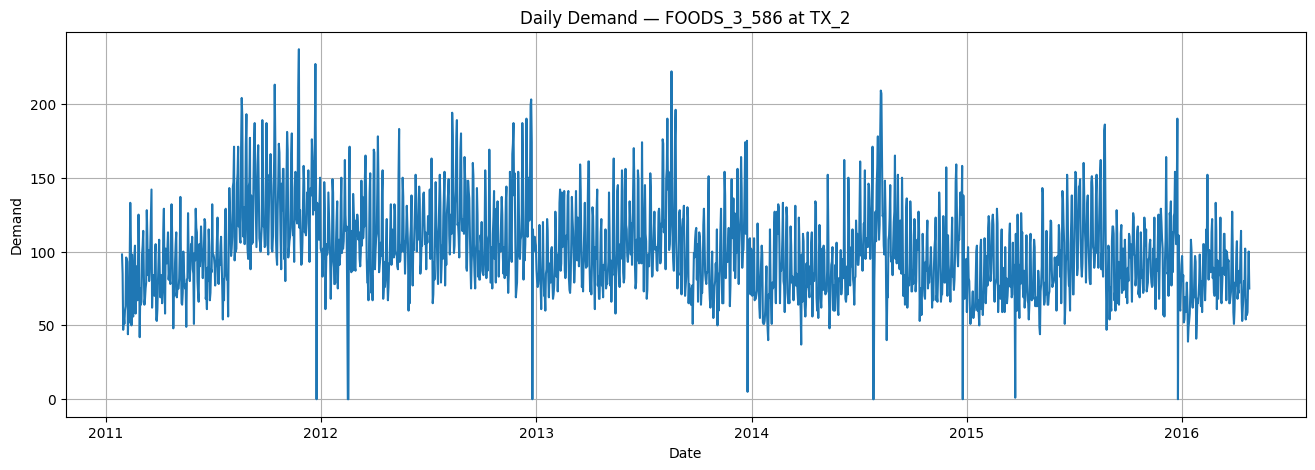

In [25]:
plt.figure(figsize=(16, 5))

plt.plot(
    candidate_series.index,
    candidate_series["Demand"]
)

plt.title("Daily Demand — FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(True)

plt.show()

In [26]:
weekly_pattern = (
    candidate_series
    .groupby("weekday")["Demand"]
    .mean()
)

print(weekly_pattern)

weekday
Friday       104.838828
Monday        88.183150
Saturday     128.127737
Sunday       123.427007
Thursday      91.479853
Tuesday       84.285714
Wednesday     85.091575
Name: Demand, dtype: float64


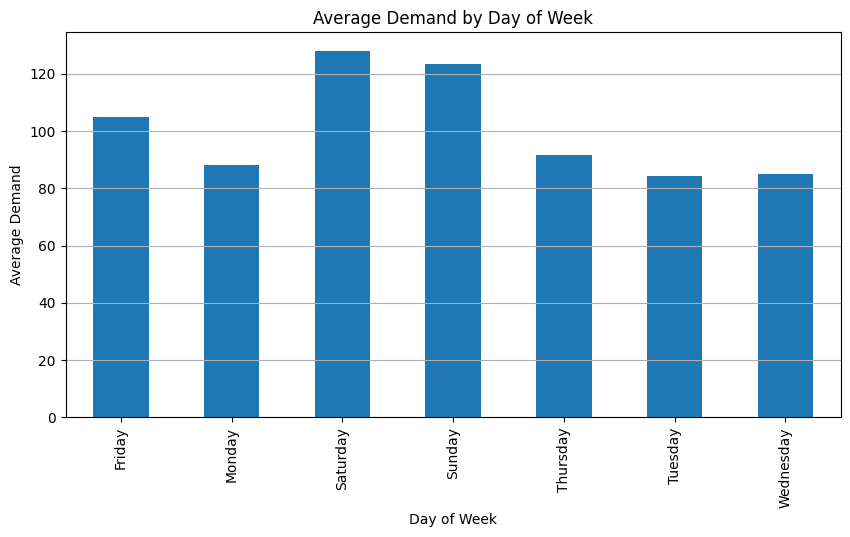

In [27]:
plt.figure(figsize=(10, 5))

weekly_pattern.plot(kind="bar")

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.grid(axis="y")

plt.show()

In [28]:

ts = candidate_series[["Demand"]].copy()
ts = ts.sort_index()
n = len(ts)


train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = ts.iloc[:train_end]
validation = ts.iloc[train_end:val_end]
test = ts.iloc[val_end:]

print("Total observations:", len(ts))
print("Training observations:", len(train))
print("Validation observations:", len(validation))
print("Test observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nValidation period:")
print(validation.index.min(), "to", validation.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Total observations: 1913
Training observations: 1339
Validation observations: 287
Test observations: 287

Training period:
2011-01-29 00:00:00 to 2014-09-28 00:00:00

Validation period:
2014-09-29 00:00:00 to 2015-07-12 00:00:00

Test period:
2015-07-13 00:00:00 to 2016-04-24 00:00:00


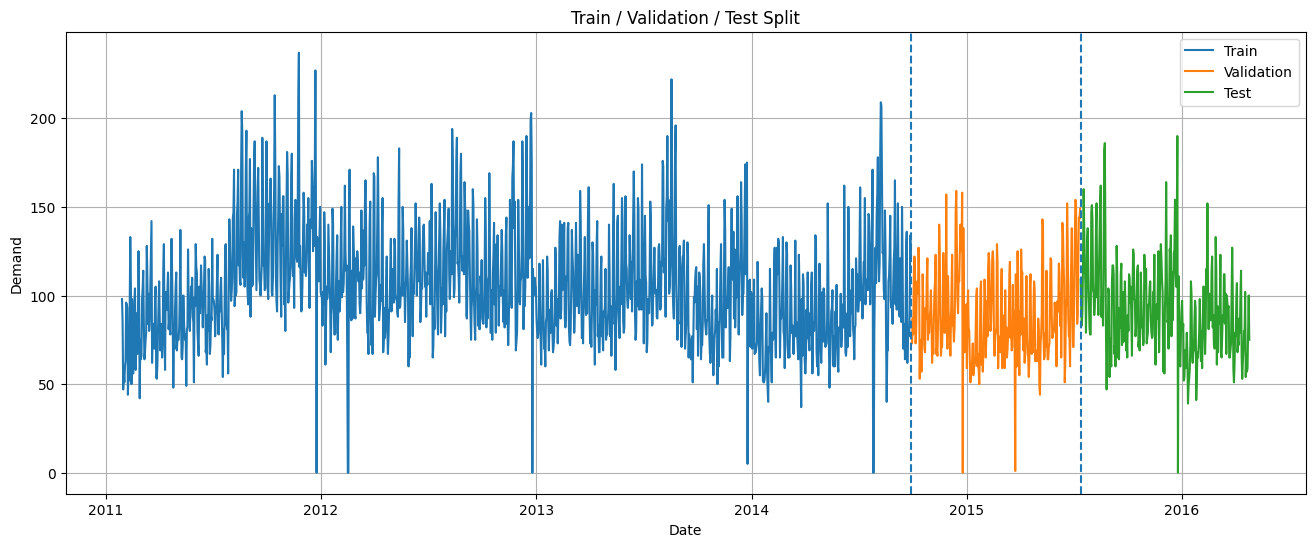

In [29]:
plt.figure(figsize=(16, 6))

plt.plot(train.index, train["Demand"], label="Train")
plt.plot(validation.index, validation["Demand"], label="Validation")
plt.plot(test.index, test["Demand"], label="Test")

plt.axvline(validation.index[0], linestyle="--")
plt.axvline(test.index[0], linestyle="--")

plt.title("Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

### checking stationarity

In [30]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train["Demand"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -3.7949866628718008
p-value: 0.002959026497580196


C:\Users\salon\AppData\Local\Temp\ipykernel_7760\1537485731.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train["Demand"])


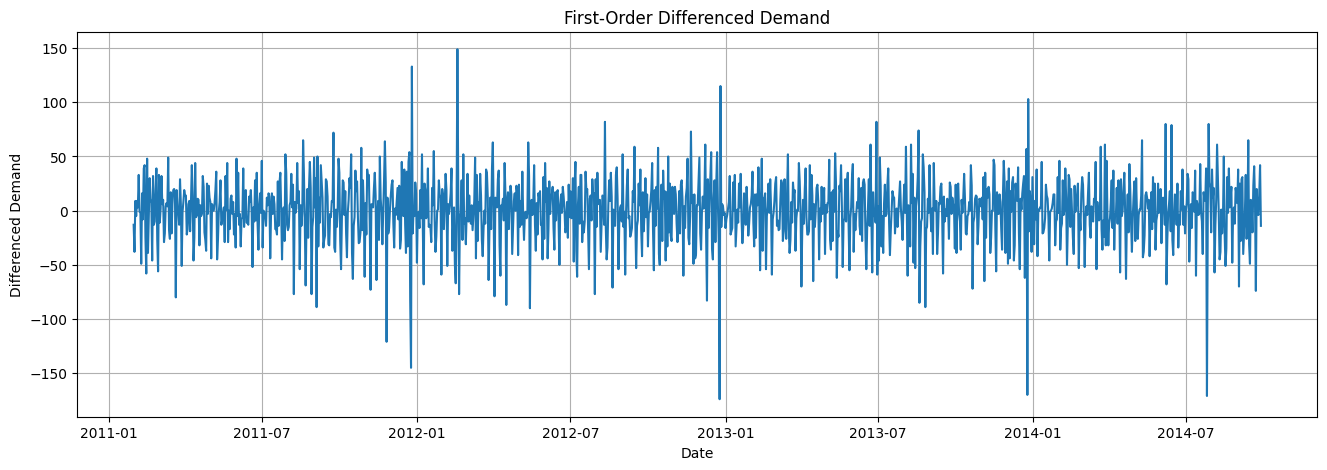

In [31]:
train_diff = train["Demand"].diff().dropna()

plt.figure(figsize=(16, 5))

plt.plot(train_diff)

plt.title("First-Order Differenced Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand")

plt.grid(True)
plt.show()

In [32]:
adf_diff = adfuller(train_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: -12.71538150969984
p-value: 1.0091577065690542e-23


C:\Users\salon\AppData\Local\Temp\ipykernel_7760\3502219651.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(train_diff)


In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

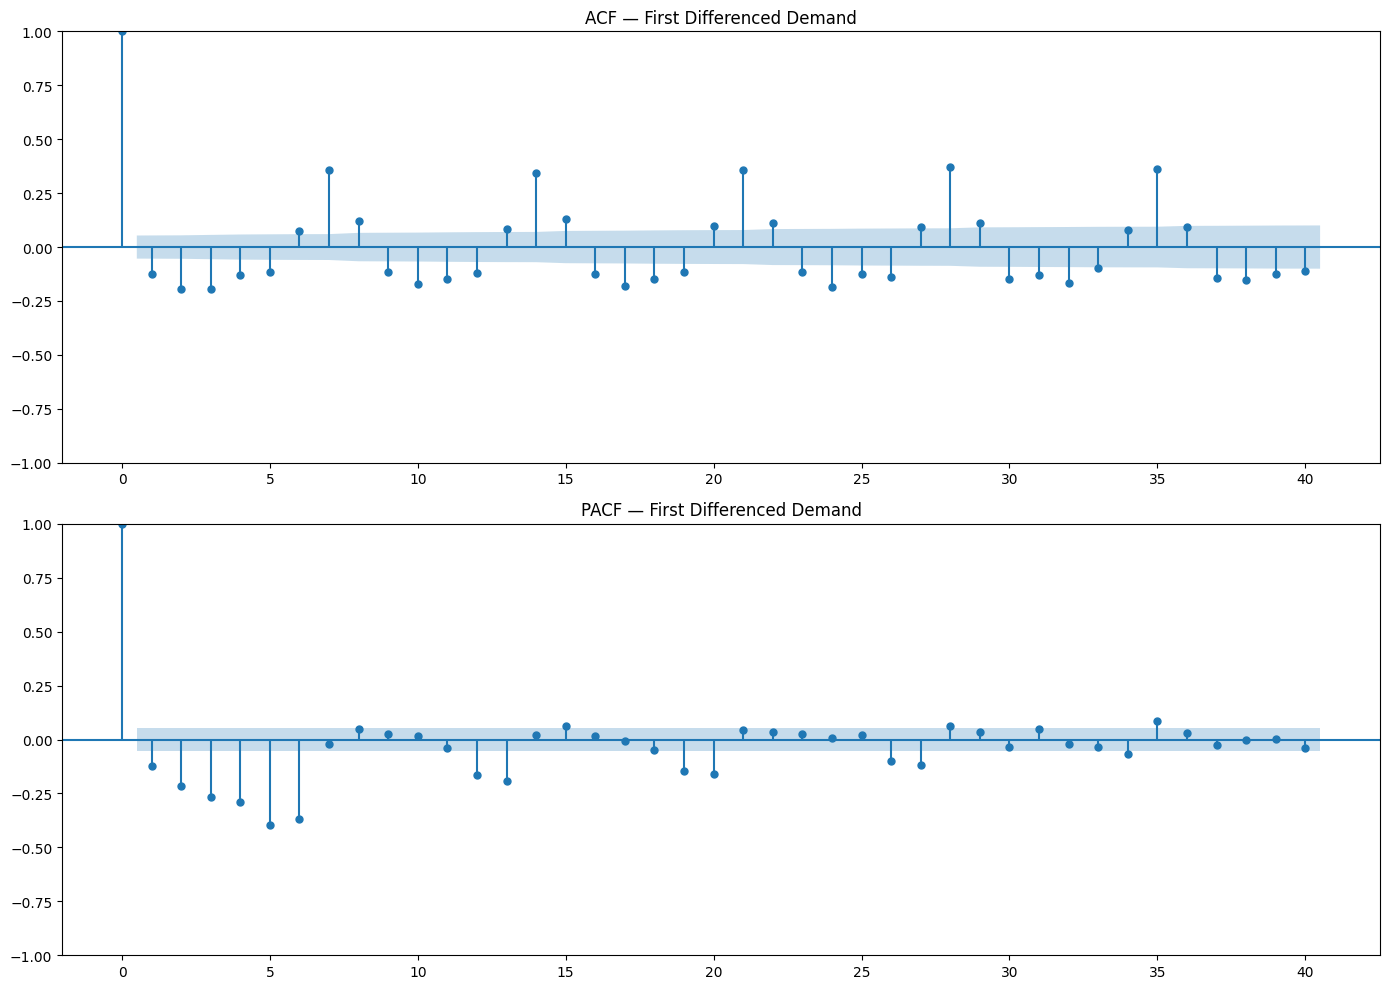

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(train_diff, lags=40, ax=ax[0])
plot_pacf(train_diff, lags=40, ax=ax[1])

ax[0].set_title("ACF — First Differenced Demand")
ax[1].set_title("PACF — First Differenced Demand")

plt.tight_layout()
plt.show()

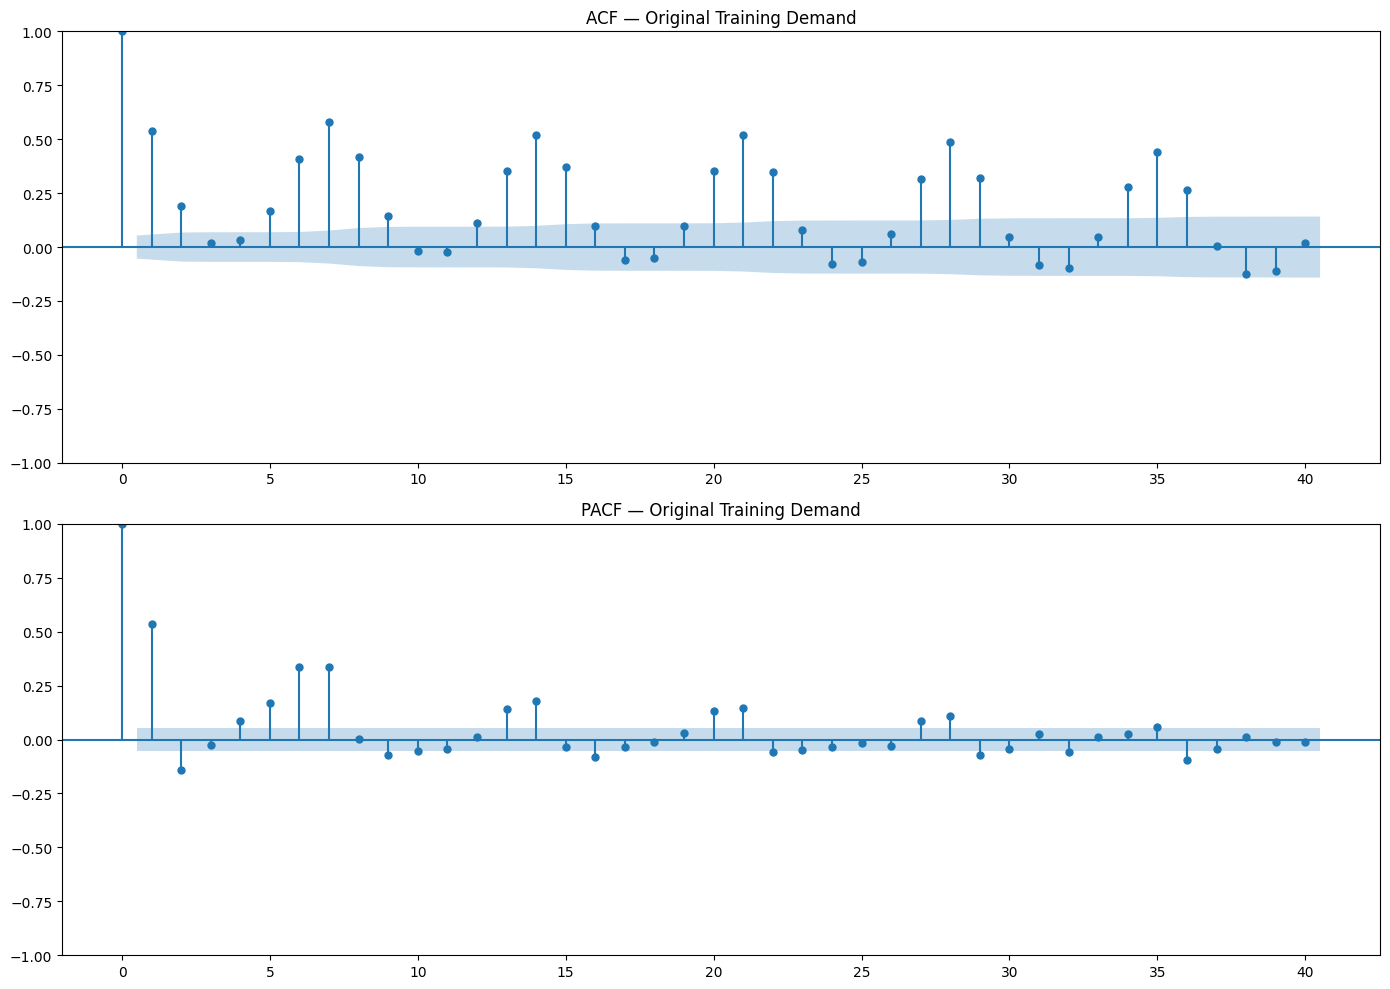

In [ ]:
# original-series ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(
    train["Demand"],
    lags=40,
    ax=ax[0]
)

plot_pacf(
    train["Demand"],
    lags=40,
    ax=ax[1],
    method="ywm"
)

ax[0].set_title("ACF — Original Training Demand")
ax[1].set_title("PACF — Original Training Demand")

plt.tight_layout()
plt.show()

In [37]:
print("ACF — important lags")

for lag in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 21, 28, 35]:
    print(f"Lag {lag}: {acf_values[lag]:.4f}")

print("\nPACF — important lags")

for lag in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 21, 28, 35]:
    print(f"Lag {lag}: {pacf_values[lag]:.4f}")

ACF — important lags
Lag 1: 0.5371
Lag 2: 0.1882
Lag 3: 0.0205
Lag 4: 0.0345
Lag 5: 0.1669
Lag 6: 0.4073
Lag 7: 0.5784
Lag 8: 0.4166
Lag 9: 0.1445
Lag 10: -0.0181
Lag 14: 0.5212
Lag 21: 0.5171
Lag 28: 0.4891
Lag 35: 0.4411

PACF — important lags
Lag 1: 0.5371
Lag 2: -0.1408
Lag 3: -0.0275
Lag 4: 0.0863
Lag 5: 0.1689
Lag 6: 0.3347
Lag 7: 0.3372
Lag 8: 0.0007
Lag 9: -0.0722
Lag 10: -0.0508
Lag 14: 0.1769
Lag 21: 0.1483
Lag 28: 0.1086
Lag 35: 0.0560


# First SARIMA model

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model_1 = SARIMAX(
    train["Demand"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result_1 = sarima_model_1.fit(disp=False)

print(sarima_result_1.summary())

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5962.177
Date:                           Sat, 03 Oct 2026   AIC                          11934.353
Time:                                   22:09:23   BIC                          11960.318
Sample:                               01-29-2011   HQIC                         11944.084
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9469      0.011     89.455      0.000       0.926       0.968
ma.L1         -0.7222      0.019    -38.730

In [39]:
print("AIC:", sarima_result_1.aic)
print("BIC:", sarima_result_1.bic)

AIC: 11934.353218635737
BIC: 11960.317889741817


In [40]:
sarima_forecast = sarima_result_1.get_forecast(
    steps=len(validation)
)

sarima_pred = sarima_forecast.predicted_mean

sarima_pred.index = validation.index

In [43]:
def calculate_metrics(actual, predicted):
    
    mae = mean_absolute_error(actual, predicted)
    
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )
    
    # Exclude zero actual values for MAPE
    mask = actual != 0
    
    mape = np.mean(
        np.abs(
            (actual[mask] - predicted[mask]) /
            actual[mask]
        )
    ) * 100
    
    return mae, rmse, mape

In [44]:
mae, rmse, mape = calculate_metrics(
    validation["Demand"],
    sarima_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 16.145533060480673
RMSE: 21.347879015507235
MAPE: 46.34665136393288


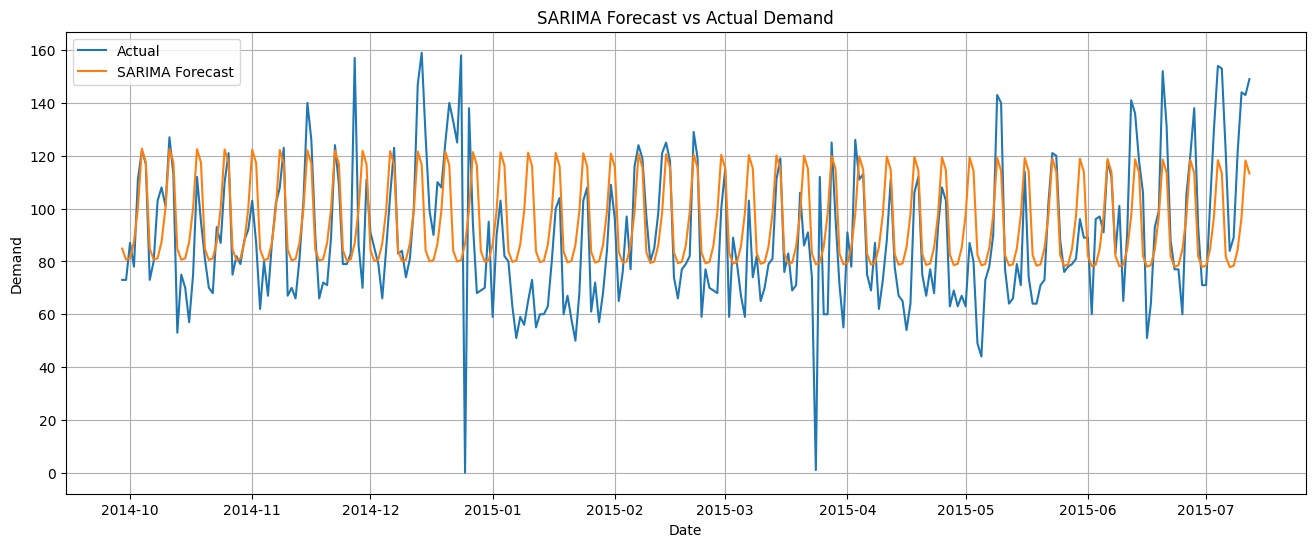

In [45]:
plt.figure(figsize=(16, 6))

plt.plot(
    validation.index,
    validation["Demand"],
    label="Actual"
)

plt.plot(
    validation.index,
    sarima_pred,
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.grid(True)

plt.show()

# Model 2

In [46]:
sarima_model_2 = SARIMAX(
    train["Demand"],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result_2 = sarima_model_2.fit(disp=False)

print(sarima_result_2.summary())

print("\nAIC:", sarima_result_2.aic)
print("BIC:", sarima_result_2.bic)

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                              Demand   No. Observations:                 1339
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -5990.961
Date:                             Sat, 03 Oct 2026   AIC                          11989.923
Time:                                     22:12:35   BIC                          12010.698
Sample:                                 01-29-2011   HQIC                         11997.709
                                      - 09-28-2014                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4429      0.014     30.900      0.000       0.415       0.471
ar.S.L7        0.9997      

In [47]:
sarima_forecast_2 = sarima_result_2.get_forecast(
    steps=len(validation)
)

sarima_pred_2 = sarima_forecast_2.predicted_mean
sarima_pred_2.index = validation.index

In [48]:
mae_2, rmse_2, mape_2 = calculate_metrics(
    validation["Demand"],
    sarima_pred_2
)

print("SARIMA Model 2")
print("----------------")
print("MAE :", mae_2)
print("RMSE:", rmse_2)
print("MAPE:", mape_2)

SARIMA Model 2
----------------
MAE : 20.776000240736323
RMSE: 25.443140469758568
MAPE: 56.36860061729729


# Model 3

In [49]:
sarima_model_3 = SARIMAX(
    train["Demand"],
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result_3 = sarima_model_3.fit(disp=False)

print("\nAIC:", sarima_result_3.aic)
print("BIC:", sarima_result_3.bic)

sarima_forecast_3 = sarima_result_3.get_forecast(
    steps=len(validation)
)

sarima_pred_3 = sarima_forecast_3.predicted_mean
sarima_pred_3.index = validation.index

mae_3, rmse_3, mape_3 = calculate_metrics(
    validation["Demand"],
    sarima_pred_3
)

print("MAE :", mae_3)
print("RMSE:", rmse_3)
print("MAPE:", mape_3)

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



AIC: 11883.341775460996
BIC: 11914.499380788291
MAE : 15.897373779694588
RMSE: 21.1368110882034
MAPE: 45.58653271930789


c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [50]:
sarima_result_3_retry = sarima_model_3.fit(
    disp=False,
    maxiter=300
)

print(sarima_result_3_retry.mle_retvals)

{'fopt': np.float64(4.432873018056175), 'gopt': array([-1.24374200e-04, -1.24557697e-04,  2.86222601e-05,  1.50382169e-03,
        1.72956760e-04,  1.83133508e-06]), 'fcalls': 651, 'warnflag': 0, 'converged': True, 'iterations': 61}


In [51]:
sarima_forecast_3_retry = sarima_result_3_retry.get_forecast(
    steps=len(validation)
)

sarima_pred_3_retry = sarima_forecast_3_retry.predicted_mean
sarima_pred_3_retry.index = validation.index

mae_3, rmse_3, mape_3 = calculate_metrics(
    validation["Demand"],
    sarima_pred_3_retry
)

print("Model 3 after retry")
print("-------------------")
print("AIC :", sarima_result_3_retry.aic)
print("BIC :", sarima_result_3_retry.bic)
print("MAE :", mae_3)
print("RMSE:", rmse_3)
print("MAPE:", mape_3)

Model 3 after retry
-------------------
AIC : 11883.233942354436
BIC : 11914.391547681731
MAE : 16.02527759106373
RMSE: 21.235456365930407
MAPE: 45.9761029707585


So far, Model 3 is the stronger candidate among these three.

# Model 4

In [52]:
sarima_model_4 = SARIMAX(
    train["Demand"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result_4 = sarima_model_4.fit(
    disp=False,
    maxiter=300
)

print(sarima_result_4.summary())

print("\nAIC:", sarima_result_4.aic)
print("BIC:", sarima_result_4.bic)

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -5930.373
Date:                           Sat, 03 Oct 2026   AIC                          11870.747
Time:                                   22:15:54   BIC                          11896.685
Sample:                               01-29-2011   HQIC                         11880.471
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9309      0.013     69.775      0.000       0.905       0.957
ma.L1         -0.6926      0.021    -33.370

In [53]:
sarima_forecast_4 = sarima_result_4.get_forecast(
    steps=len(validation)
)

sarima_pred_4 = sarima_forecast_4.predicted_mean
sarima_pred_4.index = validation.index

In [54]:
mae_4, rmse_4, mape_4 = calculate_metrics(
    validation["Demand"],
    sarima_pred_4
)

print("SARIMA Model 4")
print("----------------")
print("MAE :", mae_4)
print("RMSE:", rmse_4)
print("MAPE:", mape_4)

SARIMA Model 4
----------------
MAE : 18.138160471662175
RMSE: 23.164688967699842
MAPE: 51.36895728064441


* We initially considered seasonal differencing because the series had weekly seasonality. 
However, the original series was already stationary according to the ADF test, so I tested a model with D=1. 
Its validation MAE and RMSE were worse, so I retained D=0.

* At this point:

Model 3
SARIMA(2,0,1)(1,0,1,7)

has the lowest validation MAE and RMSE among the four tested models

In [55]:
# Residuals from the selected SARIMA Model 3
residuals_3 = sarima_result_3_retry.resid

print("Number of residuals:", len(residuals_3))
print("\nResidual statistics:")
print(residuals_3.describe())

Number of residuals: 1339

Residual statistics:
count    1339.000000
mean        0.376887
std        21.201227
min      -160.722246
25%       -11.518806
50%         0.010601
75%        11.882844
max        98.000000
dtype: float64


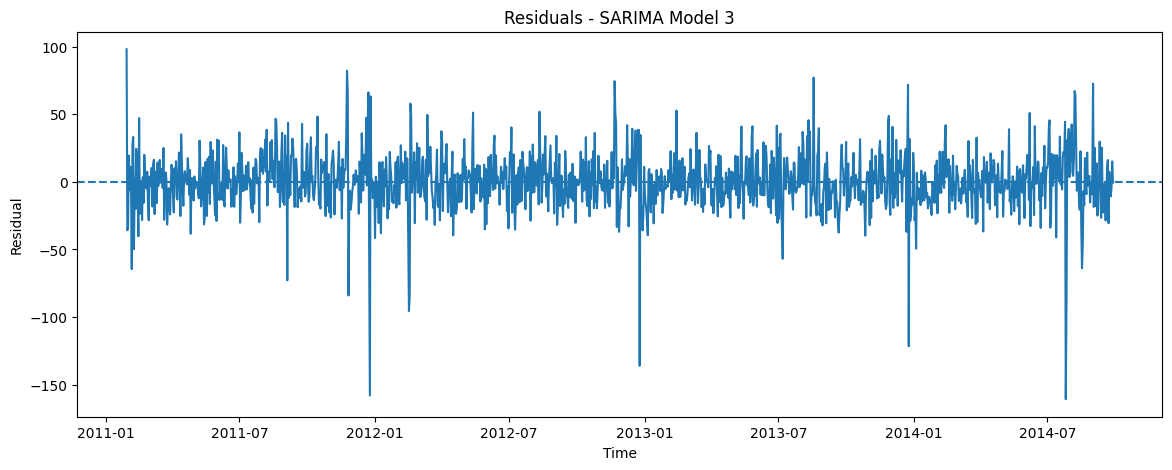

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(residuals_3)

plt.axhline(y=0, linestyle="--")

plt.title("Residuals - SARIMA Model 3")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.show()

<Figure size 1200x500 with 0 Axes>

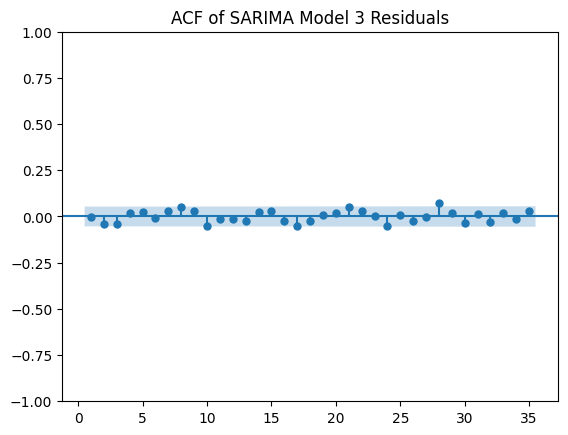

In [57]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    residuals_3,
    lags=35,
    zero=False
)

plt.title("ACF of SARIMA Model 3 Residuals")

plt.show()

In [58]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_3 = acorr_ljungbox(
    residuals_3,
    lags=[7, 14, 21, 28],
    return_df=True
)

print(ljung_box_3)

      lb_stat  lb_pvalue
7    6.505941   0.482063
14  16.640753   0.275828
21  27.330140   0.160191
28  40.327026   0.061819


The SARIMA model has captured the major temporal dependence and weekly seasonal structure sufficiently well, with no statistically significant residual autocorrelation detected by the Ljung–Box test at the tested lags.

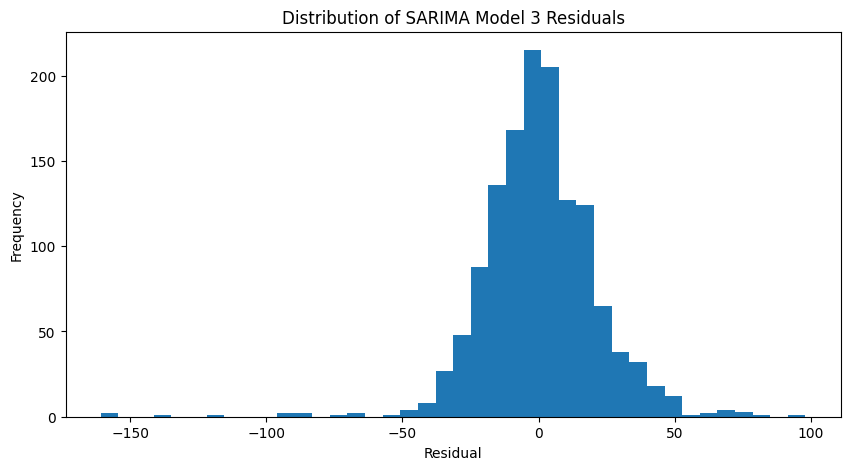

In [ ]:
# Normality check
plt.figure(figsize=(10, 5))

plt.hist(residuals_3, bins=40)

plt.title("Distribution of SARIMA Model 3 Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

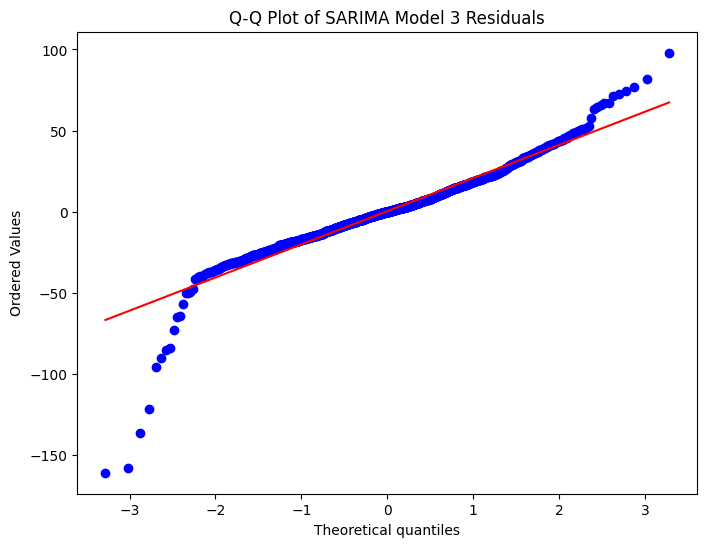

In [60]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))

stats.probplot(residuals_3, dist="norm", plot=plt)

plt.title("Q-Q Plot of SARIMA Model 3 Residuals")

plt.show()

In [61]:

# TEST SET EVALUATION  MODEL 3

sarima_test_forecast_3 = sarima_result_3_retry.get_forecast(
    steps=len(test)
)

sarima_test_pred_3 = sarima_test_forecast_3.predicted_mean

sarima_test_pred_3.index = test.index


# Calculate metrics

mae_test_3, rmse_test_3, mape_test_3 = calculate_metrics(
    test["Demand"],
    sarima_test_pred_3
)


print("SARIMA Model 3 - TEST SET")
print("--------------------------")
print("MAE :", mae_test_3)
print("RMSE:", rmse_test_3)
print("MAPE:", mape_test_3)

SARIMA Model 3 - TEST SET
--------------------------
MAE : 16.34320301893983
RMSE: 21.395087059700824
MAPE: 18.630377741843503


In [62]:
print("Test observations:", len(test))
print("Test start:", test.index.min())
print("Test end:", test.index.max())

Test observations: 287
Test start: 2015-07-13 00:00:00
Test end: 2016-04-24 00:00:00


### Can external factors such as price and calendar events improve demand forecasting beyond SARIMA?

### SARIMAX

In [63]:
# Inspect price data
print("Price data shape:", prices.shape)
print("\nColumns:")
print(prices.columns.tolist())

print("\nSelected item:")
print(
    prices[
        (prices["item_id"] == "FOODS_3_586") &
        (prices["store_id"] == "TX_2")
    ].head(20)
)

Price data shape: (6841121, 4)

Columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

Selected item:
        store_id      item_id  wm_yr_wk  sell_price
4056228     TX_2  FOODS_3_586     11101        1.48
4056229     TX_2  FOODS_3_586     11102        1.48
4056230     TX_2  FOODS_3_586     11103        1.48
4056231     TX_2  FOODS_3_586     11104        1.48
4056232     TX_2  FOODS_3_586     11105        1.48
4056233     TX_2  FOODS_3_586     11106        1.48
4056234     TX_2  FOODS_3_586     11107        1.48
4056235     TX_2  FOODS_3_586     11108        1.48
4056236     TX_2  FOODS_3_586     11109        1.48
4056237     TX_2  FOODS_3_586     11110        1.48
4056238     TX_2  FOODS_3_586     11111        1.48
4056239     TX_2  FOODS_3_586     11112        1.48
4056240     TX_2  FOODS_3_586     11113        1.48
4056241     TX_2  FOODS_3_586     11114        1.48
4056242     TX_2  FOODS_3_586     11115        1.48
4056243     TX_2  FOODS_3_586     11116        1.48
4056244  

In [64]:
selected_prices = prices[
    (prices["item_id"] == "FOODS_3_586") &
    (prices["store_id"] == "TX_2")
].copy()

print("Selected price rows:", len(selected_prices))

print("\nPrice statistics:")
print(selected_prices["sell_price"].describe())

print("\nNumber of unique prices:",
      selected_prices["sell_price"].nunique())

Selected price rows: 282

Price statistics:
count    282.000000
mean       1.595957
std        0.072529
min        1.480000
25%        1.580000
50%        1.580000
75%        1.680000
max        1.680000
Name: sell_price, dtype: float64

Number of unique prices: 3


In [65]:

# Prepare price data for selected item-store


selected_prices = prices[
    (prices["item_id"] == selected_item) &
    (prices["store_id"] == selected_store)
].copy()

selected_prices = selected_prices[
    ["wm_yr_wk", "sell_price"]
].copy()

print(selected_prices.head())
print("Price rows:", len(selected_prices))

         wm_yr_wk  sell_price
4056228     11101        1.48
4056229     11102        1.48
4056230     11103        1.48
4056231     11104        1.48
4056232     11105        1.48
Price rows: 282


In [66]:
sarimax_data = candidate_series.reset_index().merge(
    selected_prices,
    on="wm_yr_wk",
    how="left"
)

sarimax_data = sarimax_data.sort_values("date")
sarimax_data = sarimax_data.set_index("date")

print("Shape:", sarimax_data.shape)

print(
    sarimax_data[
        ["Demand", "wm_yr_wk", "sell_price"]
    ].head(20)
)

print("\nMissing prices:")
print(sarimax_data["sell_price"].isna().sum())

Shape: (1913, 10)
            Demand  wm_yr_wk  sell_price
date                                    
2011-01-29      98     11101        1.48
2011-01-30      85     11101        1.48
2011-01-31      47     11101        1.48
2011-02-01      56     11101        1.48
2011-02-02      51     11101        1.48
2011-02-03      60     11101        1.48
2011-02-04      63     11101        1.48
2011-02-05      96     11102        1.48
2011-02-06      95     11102        1.48
2011-02-07      93     11102        1.48
2011-02-08      44     11102        1.48
2011-02-09      60     11102        1.48
2011-02-10      52     11102        1.48
2011-02-11      91     11102        1.48
2011-02-12     133     11103        1.48
2011-02-13     108     11103        1.48
2011-02-14      50     11103        1.48
2011-02-15      98     11103        1.48
2011-02-16      59     11103        1.48
2011-02-17      56     11103        1.48

Missing prices:
0


In [67]:
print(
    sarimax_data[
        ["Demand", "sell_price"]
    ].corr()
)

              Demand  sell_price
Demand      1.000000   -0.187191
sell_price -0.187191    1.000000


In [68]:
print(
    sarimax_data.groupby("sell_price")["Demand"].agg(
        ["count", "mean", "std"]
    )
)

            count        mean        std
sell_price                              
1.48          385  107.698701  34.854797
1.58          889  103.776153  29.534002
1.68          639   92.510172  28.328229


In [69]:
# Add event information
print(
    sarimax_data["event_name_1"].value_counts(dropna=False).head(20)
)

print("\nEvent types:")
print(
    sarimax_data["event_type_1"].value_counts(dropna=False)
)

event_name_1
NaN                1759
SuperBowl             6
ValentinesDay         6
PresidentsDay         6
LentStart             6
LentWeek2             6
StPatricksDay         6
Purim End             6
Pesach End            5
MemorialDay           5
Mother's day          5
NBAFinalsStart        5
NBAFinalsEnd          5
Ramadan starts        5
IndependenceDay       5
NewYear               5
Thanksgiving          5
Eid al-Fitr           5
LaborDay              5
Halloween             5
Name: count, dtype: int64

Event types:
event_type_1
NaN          1759
Religious      52
National       51
Cultural       35
Sporting       16
Name: count, dtype: int64


In [70]:
sarimax_data["event_flag"] = (
    sarimax_data["event_name_1"].notna().astype(int)
)

print(
    sarimax_data["event_flag"].value_counts()
)

event_flag
0    1759
1     154
Name: count, dtype: int64


In [71]:
# final dataset
print(
    sarimax_data[
        [
            "Demand",
            "sell_price",
            "event_flag"
        ]
    ].head(20)
)

print("\nMissing values:")
print(
    sarimax_data[
        [
            "Demand",
            "sell_price",
            "event_flag"
        ]
    ].isna().sum()
)

            Demand  sell_price  event_flag
date                                      
2011-01-29      98        1.48           0
2011-01-30      85        1.48           0
2011-01-31      47        1.48           0
2011-02-01      56        1.48           0
2011-02-02      51        1.48           0
2011-02-03      60        1.48           0
2011-02-04      63        1.48           0
2011-02-05      96        1.48           0
2011-02-06      95        1.48           1
2011-02-07      93        1.48           0
2011-02-08      44        1.48           0
2011-02-09      60        1.48           0
2011-02-10      52        1.48           0
2011-02-11      91        1.48           0
2011-02-12     133        1.48           0
2011-02-13     108        1.48           0
2011-02-14      50        1.48           1
2011-02-15      98        1.48           0
2011-02-16      59        1.48           0
2011-02-17      56        1.48           0

Missing values:
Demand        0
sell_price    0
event

In [72]:

# SARIMAX train / validation / test split


sarimax_ts = sarimax_data[
    ["Demand", "sell_price", "event_flag"]
].copy()

sarimax_train = sarimax_ts.loc[train.index]
sarimax_validation = sarimax_ts.loc[validation.index]
sarimax_test = sarimax_ts.loc[test.index]

print("Train:", sarimax_train.shape)
print("Validation:", sarimax_validation.shape)
print("Test:", sarimax_test.shape)

Train: (1339, 3)
Validation: (287, 3)
Test: (287, 3)


In [73]:
# Exogenous variables
exog_train = sarimax_train[
    ["sell_price", "event_flag"]
]

exog_validation = sarimax_validation[
    ["sell_price", "event_flag"]
]

exog_test = sarimax_test[
    ["sell_price", "event_flag"]
]

print(exog_train.head())

            sell_price  event_flag
date                              
2011-01-29        1.48           0
2011-01-30        1.48           0
2011-01-31        1.48           0
2011-02-01        1.48           0
2011-02-02        1.48           0


## SARIMAX Model 1

In [74]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model_1 = SARIMAX(
    sarimax_train["Demand"],
    exog=exog_train,
    order=(2,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result_1 = sarimax_model_1.fit(
    disp=False,
    maxiter=300
)

print(sarimax_result_1.summary())

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5936.378
Date:                           Sat, 03 Oct 2026   AIC                          11888.755
Time:                                   22:46:46   BIC                          11930.299
Sample:                               01-29-2011   HQIC                         11904.325
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sell_price    67.3085     23.810      2.827      0.005      20.641     113.976
event_flag     3.4143      1.564      2.182

In [75]:
sarimax_forecast_1 = sarimax_result_1.get_forecast(
    steps=len(sarimax_validation),
    exog=exog_validation
)

sarimax_pred_1 = sarimax_forecast_1.predicted_mean

sarimax_pred_1.index = validation.index

In [76]:
mae_sarimax_1, rmse_sarimax_1, mape_sarimax_1 = calculate_metrics(
    validation["Demand"],
    sarimax_pred_1
)

print("SARIMAX Model 1 - VALIDATION")
print("--------------------------------")
print("MAE :", mae_sarimax_1)
print("RMSE:", rmse_sarimax_1)
print("MAPE:", mape_sarimax_1)

SARIMAX Model 1 - VALIDATION
--------------------------------
MAE : 22.350147707921494
RMSE: 27.00848702879255
MAPE: 60.48483489807212


For this particular item-store series and this particular combination of exogenous variables, adding price and event information did not improve the validation forecast.

In [77]:
print("AIC:", sarimax_result_1.aic)
print("BIC:", sarimax_result_1.bic)

print("\nCoefficients:")
print(
    sarimax_result_1.params[
        ["sell_price", "event_flag"]
    ]
)

print("\nP-values:")
print(
    sarimax_result_1.pvalues[
        ["sell_price", "event_flag"]
    ]
)

AIC: 11888.755058694762
BIC: 11930.298532464489

Coefficients:
sell_price    67.308511
event_flag     3.414331
dtype: float64

P-values:
sell_price    0.004701
event_flag    0.029081
dtype: float64


In [78]:
print(sarimax_result_1.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5936.378
Date:                           Sat, 03 Oct 2026   AIC                          11888.755
Time:                                   22:48:22   BIC                          11930.299
Sample:                               01-29-2011   HQIC                         11904.325
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sell_price    67.3085     23.810      2.827      0.005      20.641     113.976
event_flag     3.4143      1.564      2.182

Price was statistically significant in the fitted SARIMAX model, but its conditional coefficient was positive, whereas the raw demand-price association was negative. Therefore, I treated it as a predictive feature rather than interpreting the coefficient causally
## SARIMAX MODEL 2

In [79]:

# Exogenous variable: Price only


exog_train_price = sarimax_train[
    ["sell_price"]
]

exog_validation_price = sarimax_validation[
    ["sell_price"]
]

sarimax_model_2 = SARIMAX(
    sarimax_train["Demand"],
    exog=exog_train_price,
    order=(2,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result_2 = sarimax_model_2.fit(
    disp=False,
    maxiter=300
)

print(sarimax_result_2.summary())

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5937.965
Date:                           Sat, 03 Oct 2026   AIC                          11889.931
Time:                                   22:50:01   BIC                          11926.281
Sample:                               01-29-2011   HQIC                         11903.554
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sell_price    67.4823     23.596      2.860      0.004      21.235     113.729
ar.L1          1.2333      0.028     44.033

In [80]:

# VALIDATION FORECAST

sarimax_forecast_2 = sarimax_result_2.get_forecast(
    steps=len(sarimax_validation),
    exog=exog_validation_price
)

sarimax_pred_2 = sarimax_forecast_2.predicted_mean
sarimax_pred_2.index = validation.index


# METRICS

mae_sarimax_2, rmse_sarimax_2, mape_sarimax_2 = calculate_metrics(
    validation["Demand"],
    sarimax_pred_2
)

print("SARIMAX Model 2 - VALIDATION")
print("--------------------------------")
print("MAE :", mae_sarimax_2)
print("RMSE:", rmse_sarimax_2)
print("MAPE:", mape_sarimax_2)

SARIMAX Model 2 - VALIDATION
--------------------------------
MAE : 22.192782481652475
RMSE: 26.837903689117944
MAPE: 60.289256049682535


In [81]:
# --------------------------------------------------
# SARIMAX MODEL 3
# ARIMA ORDER = (1,0,1)
# SEASONAL ORDER = (1,0,1,7)
# EXOGENOUS = PRICE + EVENT
# --------------------------------------------------

sarimax_model_3 = SARIMAX(
    sarimax_train["Demand"],
    exog=sarimax_train[["sell_price", "event_flag"]],
    order=(1,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result_3 = sarimax_model_3.fit(
    disp=False,
    maxiter=300
)

print(sarimax_result_3.summary())

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1339
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5959.869
Date:                           Sat, 03 Oct 2026   AIC                          11933.738
Time:                                   22:53:25   BIC                          11970.088
Sample:                               01-29-2011   HQIC                         11947.361
                                    - 09-28-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sell_price    67.1169     21.227      3.162      0.002      25.513     108.720
event_flag     5.4218      1.569      3.456

In [82]:
# --------------------------------------------------
# VALIDATION FORECAST
# --------------------------------------------------

sarimax_forecast_3 = sarimax_result_3.get_forecast(
    steps=len(sarimax_validation),
    exog=sarimax_validation[["sell_price", "event_flag"]]
)

sarimax_pred_3 = sarimax_forecast_3.predicted_mean
sarimax_pred_3.index = validation.index


# --------------------------------------------------
# METRICS
# --------------------------------------------------

mae_sarimax_3, rmse_sarimax_3, mape_sarimax_3 = calculate_metrics(
    validation["Demand"],
    sarimax_pred_3
)

print("SARIMAX Model 3 - VALIDATION")
print("--------------------------------")
print("MAE :", mae_sarimax_3)
print("RMSE:", rmse_sarimax_3)
print("MAPE:", mape_sarimax_3)

SARIMAX Model 3 - VALIDATION
--------------------------------
MAE : 21.419164084686084
RMSE: 26.132808953816543
MAPE: 58.43652035673359


* I initially developed SARIMA and then extended it to SARIMAX by incorporating price and calendar-event information. 
* I tested different specifications, but for this particular item-store series, the exogenous variables did not improve out-of-sample performance. 
* Therefore, I selected the simpler SARIMA model based on validation performance and residual diagnostics

In [83]:
final_sarima = SARIMAX(
    ts["Demand"],
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(
    disp=False,
    maxiter=300
)

print(final_sarima_result.summary())

c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\salon\OneDrive\Desktop\Projects\Demand Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                 1913
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -8430.576
Date:                           Sat, 03 Oct 2026   AIC                          16873.153
Time:                                   22:55:57   BIC                          16906.463
Sample:                               01-29-2011   HQIC                         16885.414
                                    - 04-24-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1933      0.025     48.233      0.000       1.145       1.242
ar.L2         -0.2155      0.020    -10.689

In [84]:
forecast_result = final_sarima_result.get_forecast(steps=28)

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

print(forecast_mean)

2016-04-25     59.468266
2016-04-26     59.557074
2016-04-27     61.308892
2016-04-28     67.208405
2016-04-29     79.158724
2016-04-30     99.613542
2016-05-01     95.802697
2016-05-02     65.875155
2016-05-03     62.715234
2016-05-04     63.693831
2016-05-05     69.366506
2016-05-06     81.207054
2016-05-07    101.571739
2016-05-08     97.704533
2016-05-09     67.751684
2016-05-10     64.539623
2016-05-11     65.463280
2016-05-12     71.077522
2016-05-13     82.854505
2016-05-14    103.147917
2016-05-15     99.236874
2016-05-16     69.269573
2016-05-17     66.015665
2016-05-18     66.894324
2016-05-19     72.459781
2016-05-20     84.182578
2016-05-21    104.413839
2016-05-22    100.467792
Freq: D, Name: predicted_mean, dtype: float64


In [87]:
# Load the M5 evaluation dataset

sales_evaluation = pd.read_csv(
    "../data/sales_train_evaluation.csv"
)

print(sales_evaluation.shape)
print(sales_evaluation.head())

(30490, 1947)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_1

In [88]:
# Get the actual 28-day future demand
selected_eval = sales_evaluation[
    (sales_evaluation["item_id"] == selected_item) &
    (sales_evaluation["store_id"] == selected_store)
].copy()

future_demand = selected_eval[
    [f"d_{i}" for i in range(1914, 1942)]
].T

future_demand.columns = ["Demand"]

future_demand.index = pd.date_range(
    start="2016-04-25",
    periods=28,
    freq="D"
)

print(future_demand)

            Demand
2016-04-25      79
2016-04-26      75
2016-04-27      71
2016-04-28      61
2016-04-29      86
2016-04-30     119
2016-05-01      96
2016-05-02      36
2016-05-03      60
2016-05-04      72
2016-05-05      92
2016-05-06      84
2016-05-07     117
2016-05-08      96
2016-05-09      72
2016-05-10      62
2016-05-11      69
2016-05-12      87
2016-05-13      85
2016-05-14      83
2016-05-15     103
2016-05-16      73
2016-05-17      86
2016-05-18      76
2016-05-19      53
2016-05-20      96
2016-05-21      79
2016-05-22     117


In [89]:
# Align forecast and actual demand
comparison = pd.DataFrame({
    "Actual": future_demand["Demand"],
    "Forecast": forecast_mean
})

comparison["Error"] = (
    comparison["Actual"] - comparison["Forecast"]
)

comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

print(comparison)

            Actual    Forecast      Error  Absolute_Error
2016-04-25      79   59.468266  19.531734       19.531734
2016-04-26      75   59.557074  15.442926       15.442926
2016-04-27      71   61.308892   9.691108        9.691108
2016-04-28      61   67.208405  -6.208405        6.208405
2016-04-29      86   79.158724   6.841276        6.841276
2016-04-30     119   99.613542  19.386458       19.386458
2016-05-01      96   95.802697   0.197303        0.197303
2016-05-02      36   65.875155 -29.875155       29.875155
2016-05-03      60   62.715234  -2.715234        2.715234
2016-05-04      72   63.693831   8.306169        8.306169
2016-05-05      92   69.366506  22.633494       22.633494
2016-05-06      84   81.207054   2.792946        2.792946
2016-05-07     117  101.571739  15.428261       15.428261
2016-05-08      96   97.704533  -1.704533        1.704533
2016-05-09      72   67.751684   4.248316        4.248316
2016-05-10      62   64.539623  -2.539623        2.539623
2016-05-11    

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = comparison["Actual"]
predicted = comparison["Forecast"]

mae_28 = mean_absolute_error(actual, predicted)

rmse_28 = np.sqrt(
    mean_squared_error(actual, predicted)
)

non_zero = actual != 0

mape_28 = (
    np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100
)

print("28-Day Future Evaluation")
print("-------------------------")
print("MAE :", mae_28)
print("RMSE:", rmse_28)
print("MAPE:", mape_28)

28-Day Future Evaluation
-------------------------
MAE : 11.396513087828698
RMSE: 14.083884459383103
MAPE: 15.537894844097098


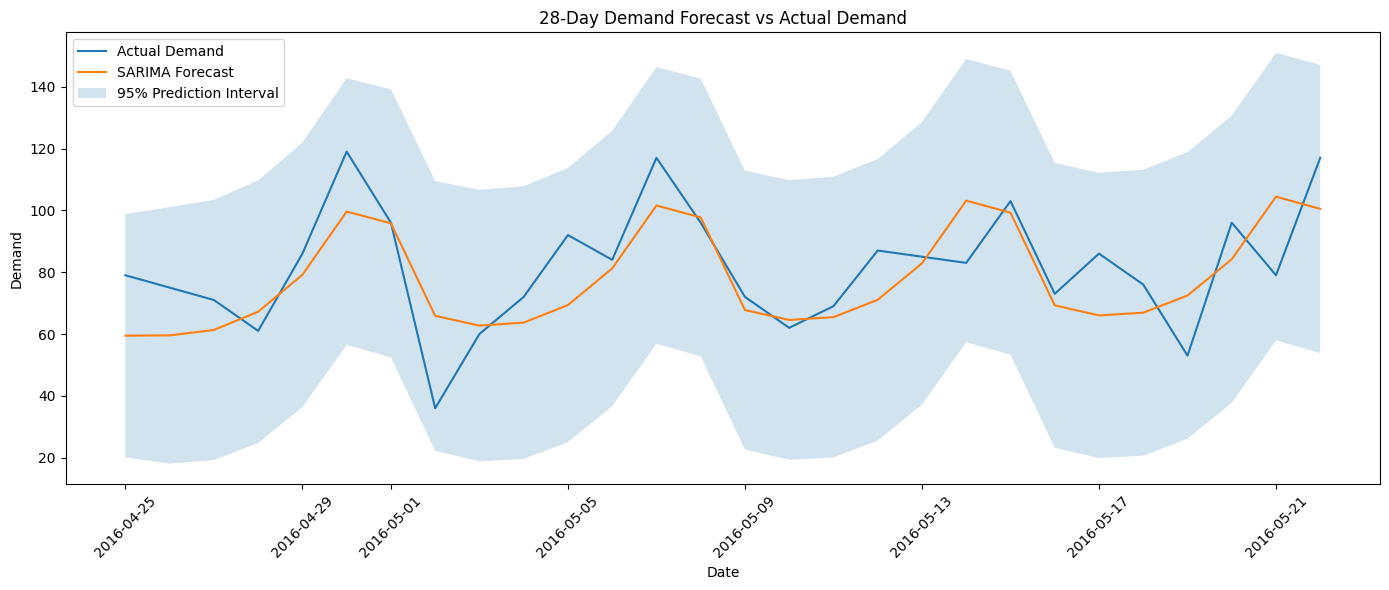

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual Demand"
)

plt.plot(
    comparison.index,
    comparison["Forecast"],
    label="SARIMA Forecast"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("28-Day Demand Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Inventory Optimization

In [92]:
# View the 28-day forecast with uncertainty

forecast_table = pd.DataFrame({
    "Forecast": forecast_mean,
    "Lower_95": forecast_ci.iloc[:, 0],
    "Upper_95": forecast_ci.iloc[:, 1]
})

print(forecast_table)

              Forecast   Lower_95    Upper_95
2016-04-25   59.468266  20.107544   98.828989
2016-04-26   59.557074  18.075223  101.038925
2016-04-27   61.308892  19.216107  103.401677
2016-04-28   67.208405  24.730728  109.686083
2016-04-29   79.158724  36.355559  121.961888
2016-04-30   99.613542  56.512600  142.714485
2016-05-01   95.802697  52.424093  139.181301
2016-05-02   65.875155  22.225230  109.525081
2016-05-03   62.715234  18.817780  106.612688
2016-05-04   63.693831  19.565514  107.822148
2016-05-05   69.366506  25.021709  113.711303
2016-05-06   81.207054  36.658965  125.755143
2016-05-07  101.571739  56.832632  146.310845
2016-05-08   97.704533  52.785840  142.623225
2016-05-09   67.751684  22.655290  112.848078
2016-05-10   64.539623  19.281696  109.797550
2016-05-11   65.463280  20.054598  110.871963
2016-05-12   71.077522  25.527259  116.627785
2016-05-13   82.854505  37.171066  128.537943
2016-05-14  103.147917  57.339148  148.956687
2016-05-15   99.236874  53.310053 

In [93]:
forecast_table["Uncertainty"] = (
    forecast_table["Upper_95"] -
    forecast_table["Lower_95"]
)

print(forecast_table[["Forecast", "Uncertainty"]])

              Forecast  Uncertainty
2016-04-25   59.468266    78.721446
2016-04-26   59.557074    82.963702
2016-04-27   61.308892    84.185571
2016-04-28   67.208405    84.955356
2016-04-29   79.158724    85.606328
2016-04-30   99.613542    86.201885
2016-05-01   95.802697    86.757208
2016-05-02   65.875155    87.299851
2016-05-03   62.715234    87.794908
2016-05-04   63.693831    88.256635
2016-05-05   69.366506    88.689594
2016-05-06   81.207054    89.096179
2016-05-07  101.571739    89.478212
2016-05-08   97.704533    89.837385
2016-05-09   67.751684    90.192788
2016-05-10   64.539623    90.515854
2016-05-11   65.463280    90.817365
2016-05-12   71.077522    91.100527
2016-05-13   82.854505    91.366876
2016-05-14  103.147917    91.617539
2016-05-15   99.236874    91.853642
2016-05-16   69.269573    92.090111
2016-05-17   66.015665    92.303767
2016-05-18   66.894324    92.503064
2016-05-19   72.459781    92.690370
2016-05-20   84.182578    92.866725
2016-05-21  104.413839    93

In [94]:
# Residuals from the final SARIMA model

final_residuals = final_sarima_result.resid

residual_std = final_residuals.std()

print("Residual standard deviation:", residual_std)

Residual standard deviation: 20.427828470769384


In [95]:
# 7-day expected demand

lead_time = 7

lead_time_forecast = forecast_mean.iloc[:lead_time]

expected_lead_time_demand = lead_time_forecast.sum()

print("Expected demand during lead time:",
      expected_lead_time_demand)

Expected demand during lead time: 522.1176002839878


In [96]:
import numpy as np

service_level = 0.95
z = 1.645

lead_time = 7

lead_time_std = residual_std * np.sqrt(lead_time)

safety_stock = z * lead_time_std

print("Daily residual std:", residual_std)
print("Lead-time demand std:", lead_time_std)
print("Safety stock:", safety_stock)

Daily residual std: 20.427828470769384
Lead-time demand std: 54.04695395874067
Safety stock: 88.90723926212841


In [97]:
reorder_point = (
    expected_lead_time_demand +
    safety_stock
)

print("Expected lead-time demand:",
      expected_lead_time_demand)

print("Safety stock:",
      safety_stock)

print("Reorder point:",
      reorder_point)

Expected lead-time demand: 522.1176002839878
Safety stock: 88.90723926212841
Reorder point: 611.0248395461163


If the inventory position falls to approximately 611 units, we should trigger a replenishment order. The first 7 forecasted days imply expected demand of about 522 units, while approximately 89 additional units are held as safety stock to protect against demand uncertainty at a 95% target service level.

In [98]:
# Calculate annualized demand from historical data

historical_days = len(ts)

average_daily_demand = ts["Demand"].mean()

annual_demand = average_daily_demand * 365

print("Average daily demand:", average_daily_demand)
print("Annualized demand:", annual_demand)

Average daily demand: 100.80240460010455
Annualized demand: 36792.87767903816


In [99]:
ordering_cost = 50      # cost per order
holding_cost = 2        # cost of holding 1 unit for 1 year

In [100]:
import math

D = annual_demand
S = ordering_cost
H = holding_cost

EOQ = math.sqrt((2 * D * S) / H)

print("Annual demand:", D)
print("Ordering cost:", S)
print("Holding cost:", H)
print("EOQ:", EOQ)

Annual demand: 36792.87767903816
Ordering cost: 50
Holding cost: 2
EOQ: 1356.3347241562121


In [101]:
# Inventory policy parameters

lead_time = 7
service_level = 0.95

safety_stock = 88.90723926212841
reorder_point = 611.0248395461163
EOQ = 1356.3347241562121

initial_inventory = reorder_point

print("Lead time:", lead_time)
print("Safety stock:", safety_stock)
print("Reorder point:", reorder_point)
print("EOQ:", EOQ)
print("Initial inventory:", initial_inventory)

Lead time: 7
Safety stock: 88.90723926212841
Reorder point: 611.0248395461163
EOQ: 1356.3347241562121
Initial inventory: 611.0248395461163


## Extract the 28-day actual future demand

In [ ]:
# Load evaluation dataset
sales_evaluation = pd.read_csv(
    "../data/sales_train_evaluation.csv"
)

selected_row = sales_evaluation[
    (sales_evaluation["item_id"] == selected_item) &
    (sales_evaluation["store_id"] == selected_store)
].iloc[0]

future_columns = [f"d_{i}" for i in range(1914, 1942)]

actual_future_demand = selected_row[future_columns].astype(float).values


future_dates = pd.date_range(
    start="2016-04-25",
    periods=28,
    freq="D"
)

print("Number of future observations:", len(actual_future_demand))
print("First 5 actual demands:", actual_future_demand[:5])
print("Start date:", future_dates[0])
print("End date:", future_dates[-1])

Number of future observations: 28
First 5 actual demands: [79. 75. 71. 61. 86.]
Start date: 2016-04-25 00:00:00
End date: 2016-05-22 00:00:00


In [106]:
future_demand = pd.DataFrame({
    "date": future_dates,
    "actual_demand": actual_future_demand
})

future_demand.head()

,date,actual_demand
0,2016-04-25,79.0
1,2016-04-26,75.0
2,2016-04-27,71.0
3,2016-04-28,61.0
4,2016-04-29,86.0


In [107]:
print("Number of days:", len(future_demand))
print("Start date:", future_demand["date"].min())
print("End date:", future_demand["date"].max())

Number of days: 28
Start date: 2016-04-25 00:00:00
End date: 2016-05-22 00:00:00


In [108]:
# Inventory simulation

lead_time = 7
reorder_point = 611
order_quantity = 1356
initial_inventory = 611

inventory = initial_inventory

# Orders that are currently in transit
orders_in_transit = []

simulation_results = []

for i in range(len(future_demand)):

    date = future_demand.iloc[i]["date"]
    demand = future_demand.iloc[i]["actual_demand"]

    # Receive orders whose arrival date is today
    arrivals_today = 0

    remaining_orders = []

    for order in orders_in_transit:
        if order["arrival_day"] == i:
            arrivals_today += order["quantity"]
        else:
            remaining_orders.append(order)

    orders_in_transit = remaining_orders

    # Add received inventory
    inventory += arrivals_today

    beginning_inventory = inventory

    # Satisfy demand
    units_sold = min(inventory, demand)

    stockout_units = max(0, demand - inventory)

    inventory -= units_sold

    # Inventory position = on-hand + inventory already ordered
    inventory_on_order = sum(
        order["quantity"] for order in orders_in_transit
    )

    inventory_position = inventory + inventory_on_order

    # Decide whether to place a new order
    order_placed = 0
    order_arrival_day = None

    if inventory_position <= reorder_point:

        order_placed = order_quantity
        order_arrival_day = i + lead_time

        orders_in_transit.append({
            "quantity": order_quantity,
            "arrival_day": order_arrival_day
        })

    inventory_on_order_after_order = sum(
        order["quantity"] for order in orders_in_transit
    )

    inventory_position_after_order = (
        inventory + inventory_on_order_after_order
    )

    simulation_results.append({
        "date": date,
        "beginning_inventory": beginning_inventory,
        "demand": demand,
        "units_sold": units_sold,
        "stockout_units": stockout_units,
        "received_inventory": arrivals_today,
        "order_placed": order_placed,
        "inventory_on_order": inventory_on_order_after_order,
        "ending_inventory": inventory,
        "inventory_position": inventory_position_after_order
    })

inventory_simulation = pd.DataFrame(simulation_results)

inventory_simulation.head(10)

,date,beginning_inventory,demand,units_sold,stockout_units,received_inventory,order_placed,inventory_on_order,ending_inventory,inventory_position
0,2016-04-25,611.0,79.0,79.0,0,0,1356,1356,532.0,1888.0
1,2016-04-26,532.0,75.0,75.0,0,0,0,1356,457.0,1813.0
2,2016-04-27,457.0,71.0,71.0,0,0,0,1356,386.0,1742.0
3,2016-04-28,386.0,61.0,61.0,0,0,0,1356,325.0,1681.0
4,2016-04-29,325.0,86.0,86.0,0,0,0,1356,239.0,1595.0
5,2016-04-30,239.0,119.0,119.0,0,0,0,1356,120.0,1476.0
6,2016-05-01,120.0,96.0,96.0,0,0,0,1356,24.0,1380.0
7,2016-05-02,1380.0,36.0,36.0,0,1356,0,0,1344.0,1344.0
8,2016-05-03,1344.0,60.0,60.0,0,0,0,0,1284.0,1284.0
9,2016-05-04,1284.0,72.0,72.0,0,0,0,0,1212.0,1212.0


In [109]:
total_demand = inventory_simulation["demand"].sum()

total_units_sold = inventory_simulation["units_sold"].sum()

total_stockout_units = inventory_simulation["stockout_units"].sum()

stockout_days = (
    inventory_simulation["stockout_units"] > 0
).sum()

number_of_orders = (
    inventory_simulation["order_placed"] > 0
).sum()

average_inventory = (
    inventory_simulation["ending_inventory"].mean()
)

fill_rate = total_units_sold / total_demand

print("Total demand:", total_demand)
print("Total units sold:", total_units_sold)
print("Total stockout units:", total_stockout_units)
print("Stockout days:", stockout_days)
print("Number of orders:", number_of_orders)
print("Average inventory:", average_inventory)
print("Fill rate:", fill_rate)
print("Fill rate (%):", fill_rate * 100)

Total demand: 2285.0
Total units sold: 2285.0
Total stockout units: 0
Stockout days: 0
Number of orders: 2
Average inventory: 663.0357142857143
Fill rate: 1.0
Fill rate (%): 100.0


In [110]:
holding_cost_per_unit_day = 2 / 365
stockout_cost_per_unit = 5
# Holding cost
total_holding_cost = (
    inventory_simulation["ending_inventory"].sum()
    * holding_cost_per_unit_day
)

# Stockout cost
total_stockout_cost = (
    inventory_simulation["stockout_units"].sum()
    * stockout_cost_per_unit
)

# Ordering cost
ordering_cost_per_order = 50

total_ordering_cost = (
    number_of_orders * ordering_cost_per_order
)

# Total inventory cost
total_inventory_cost = (
    total_holding_cost
    + total_stockout_cost
    + total_ordering_cost
)

print("Holding cost:", total_holding_cost)
print("Stockout cost:", total_stockout_cost)
print("Ordering cost:", total_ordering_cost)
print("Total inventory cost:", total_inventory_cost)

Holding cost: 101.72602739726028
Stockout cost: 0
Ordering cost: 100
Total inventory cost: 201.72602739726028


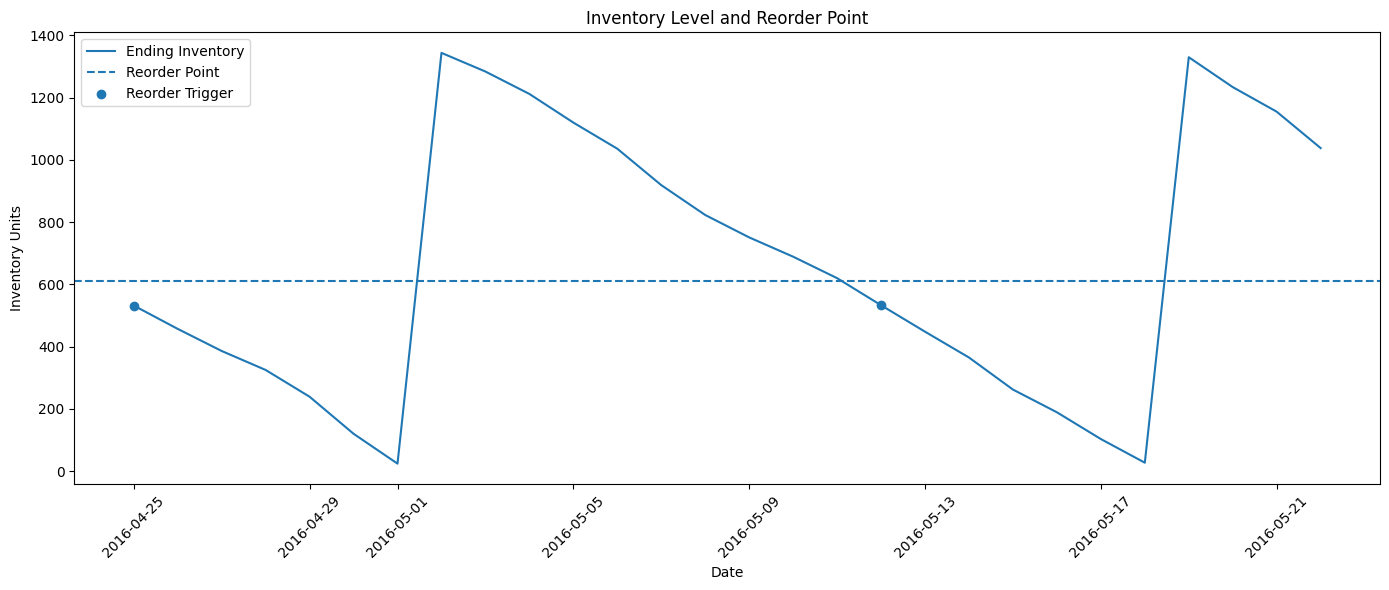

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    inventory_simulation["date"],
    inventory_simulation["ending_inventory"],
    label="Ending Inventory"
)

plt.axhline(
    reorder_point,
    linestyle="--",
    label="Reorder Point"
)

plt.scatter(
    inventory_simulation.loc[
        inventory_simulation["order_placed"] > 0,
        "date"
    ],
    inventory_simulation.loc[
        inventory_simulation["order_placed"] > 0,
        "ending_inventory"
    ],
    label="Reorder Trigger"
)

plt.xlabel("Date")
plt.ylabel("Inventory Units")
plt.title("Inventory Level and Reorder Point")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [112]:
from scipy.stats import norm

# Model residual standard deviation
residual_std = final_sarima_result.resid.std()

# Lead time
lead_time = 7

# Expected demand during lead time
lead_time_demand = forecast_mean.iloc[:lead_time].sum()

service_levels = [0.90, 0.95, 0.99]

scenario_results = []

for service_level in service_levels:

    z = norm.ppf(service_level)

    lead_time_std = residual_std * (lead_time ** 0.5)

    safety_stock = z * lead_time_std

    reorder_point = lead_time_demand + safety_stock

    scenario_results.append({
        "Service Level": service_level,
        "Z-value": z,
        "Safety Stock": safety_stock,
        "Reorder Point": reorder_point,
        "EOQ": EOQ
    })

scenario_df = pd.DataFrame(scenario_results)

scenario_df

,Service Level,Z-value,Safety Stock,Reorder Point,EOQ
0,0.90,1.281552,69.263958,591.381559,1356.334724
1,0.95,1.644854,88.899328,611.016929,1356.334724
2,0.99,2.326348,125.732016,647.849617,1356.334724


In [113]:
import pandas as pd

# --------------------------------------------------
# Scenario simulation
# --------------------------------------------------

order_quantity = round(EOQ)
lead_time = 7

scenario_simulation_results = []

for _, scenario in scenario_df.iterrows():

    service_level = scenario["Service Level"]
    reorder_point_scenario = scenario["Reorder Point"]

    inventory = reorder_point_scenario
    orders_in_transit = []

    total_stockout_units = 0
    total_units_sold = 0
    total_holding_cost = 0
    number_of_orders = 0

    for i in range(len(future_demand)):

        date = future_demand.iloc[i]["date"]
        demand = future_demand.iloc[i]["actual_demand"]

        # ------------------------------------------
        # Receive orders arriving today
        # ------------------------------------------

        arrivals_today = 0
        remaining_orders = []

        for order in orders_in_transit:

            if order["arrival_day"] == i:
                arrivals_today += order["quantity"]
            else:
                remaining_orders.append(order)

        orders_in_transit = remaining_orders

        inventory += arrivals_today

        # ------------------------------------------
        # Satisfy demand
        # ------------------------------------------

        units_sold = min(inventory, demand)

        stockout_units = max(0, demand - inventory)

        inventory -= units_sold

        total_units_sold += units_sold
        total_stockout_units += stockout_units

        # ------------------------------------------
        # Inventory position
        # ------------------------------------------

        inventory_on_order = sum(
            order["quantity"]
            for order in orders_in_transit
        )

        inventory_position = inventory + inventory_on_order

        # ------------------------------------------
        # Reorder decision
        # ------------------------------------------

        if inventory_position <= reorder_point_scenario:

            orders_in_transit.append({
                "quantity": order_quantity,
                "arrival_day": i + lead_time
            })

            number_of_orders += 1

        # ------------------------------------------
        # Holding cost
        # ------------------------------------------

        holding_cost_per_unit_day = 2 / 365

        total_holding_cost += (
            inventory * holding_cost_per_unit_day
        )

    # ------------------------------------------
    # Final metrics
    # ------------------------------------------

    total_demand = future_demand["actual_demand"].sum()

    fill_rate = total_units_sold / total_demand

    stockout_days = (
        # Re-run stockout calculation more directly later
        0
    )

    stockout_cost_per_unit = 5
    ordering_cost_per_order = 50

    total_stockout_cost = (
        total_stockout_units * stockout_cost_per_unit
    )

    total_ordering_cost = (
        number_of_orders * ordering_cost_per_order
    )

    total_cost = (
        total_holding_cost
        + total_stockout_cost
        + total_ordering_cost
    )

    scenario_simulation_results.append({
        "Service Level": service_level,
        "Reorder Point": reorder_point_scenario,
        "EOQ": order_quantity,
        "Total Demand": total_demand,
        "Units Sold": total_units_sold,
        "Stockout Units": total_stockout_units,
        "Number of Orders": number_of_orders,
        "Fill Rate": fill_rate,
        "Holding Cost": total_holding_cost,
        "Stockout Cost": total_stockout_cost,
        "Ordering Cost": total_ordering_cost,
        "Total Cost": total_cost
    })

scenario_results_df = pd.DataFrame(
    scenario_simulation_results
)

scenario_results_df

,Service Level,Reorder Point,EOQ,Total Demand,Units Sold,Stockout Units,Number of Orders,Fill Rate,Holding Cost,Stockout Cost,Ordering Cost,Total Cost
0,0.90,591.381559,1356,2285.0,2285.0,0,2,1.0,98.716075,0,100,198.716075
1,0.95,611.016929,1356,2285.0,2285.0,0,2,1.0,101.728625,0,100,201.728625
2,0.99,647.849617,1356,2285.0,2285.0,0,2,1.0,107.379667,0,100,207.379667


In [114]:
# Add stockout days to each scenario

stockout_day_results = []

for _, scenario in scenario_df.iterrows():

    service_level = scenario["Service Level"]
    reorder_point_scenario = scenario["Reorder Point"]

    inventory = reorder_point_scenario
    orders_in_transit = []

    stockout_days = 0

    for i in range(len(future_demand)):

        demand = future_demand.iloc[i]["actual_demand"]

        # Receive orders
        arrivals_today = 0
        remaining_orders = []

        for order in orders_in_transit:
            if order["arrival_day"] == i:
                arrivals_today += order["quantity"]
            else:
                remaining_orders.append(order)

        orders_in_transit = remaining_orders

        inventory += arrivals_today

        # Fulfill demand
        units_sold = min(inventory, demand)

        stockout_units = max(0, demand - inventory)

        inventory -= units_sold

        if stockout_units > 0:
            stockout_days += 1

        # Inventory position
        inventory_on_order = sum(
            order["quantity"]
            for order in orders_in_transit
        )

        inventory_position = inventory + inventory_on_order

        # Reorder
        if inventory_position <= reorder_point_scenario:

            orders_in_transit.append({
                "quantity": round(EOQ),
                "arrival_day": i + lead_time
            })

    stockout_day_results.append({
        "Service Level": service_level,
        "Stockout Days": stockout_days
    })

stockout_days_df = pd.DataFrame(stockout_day_results)

stockout_days_df

,Service Level,Stockout Days
0,0.90,0
1,0.95,0
2,0.99,0


In [115]:
final_inventory_comparison = scenario_results_df.merge(
    stockout_days_df,
    on="Service Level"
)

final_inventory_comparison

,Service Level,Reorder Point,EOQ,Total Demand,Units Sold,Stockout Units,Number of Orders,Fill Rate,Holding Cost,Stockout Cost,Ordering Cost,Total Cost,Stockout Days
0,0.90,591.381559,1356,2285.0,2285.0,0,2,1.0,98.716075,0,100,198.716075,0
1,0.95,611.016929,1356,2285.0,2285.0,0,2,1.0,101.728625,0,100,201.728625,0
2,0.99,647.849617,1356,2285.0,2285.0,0,2,1.0,107.379667,0,100,207.379667,0


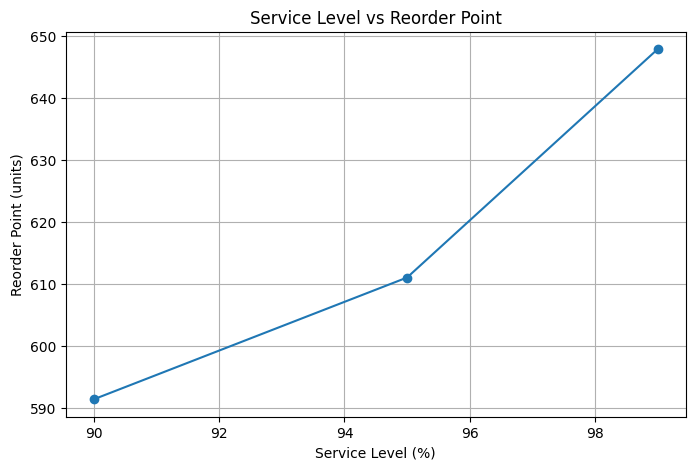

In [116]:
plt.figure(figsize=(8, 5))

plt.plot(
    scenario_df["Service Level"] * 100,
    scenario_df["Reorder Point"],
    marker="o"
)

plt.xlabel("Service Level (%)")
plt.ylabel("Reorder Point (units)")
plt.title("Service Level vs Reorder Point")
plt.grid(True)

plt.show()

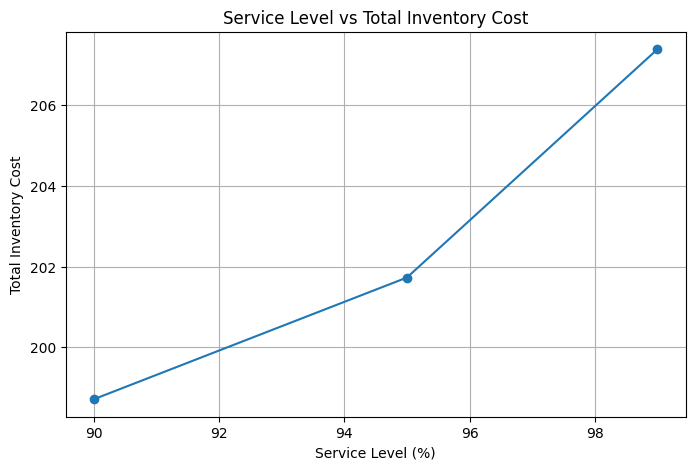

In [117]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_inventory_comparison["Service Level"] * 100,
    final_inventory_comparison["Total Cost"],
    marker="o"
)

plt.xlabel("Service Level (%)")
plt.ylabel("Total Inventory Cost")
plt.title("Service Level vs Total Inventory Cost")
plt.grid(True)

plt.show()

### final forecast + actual visualization

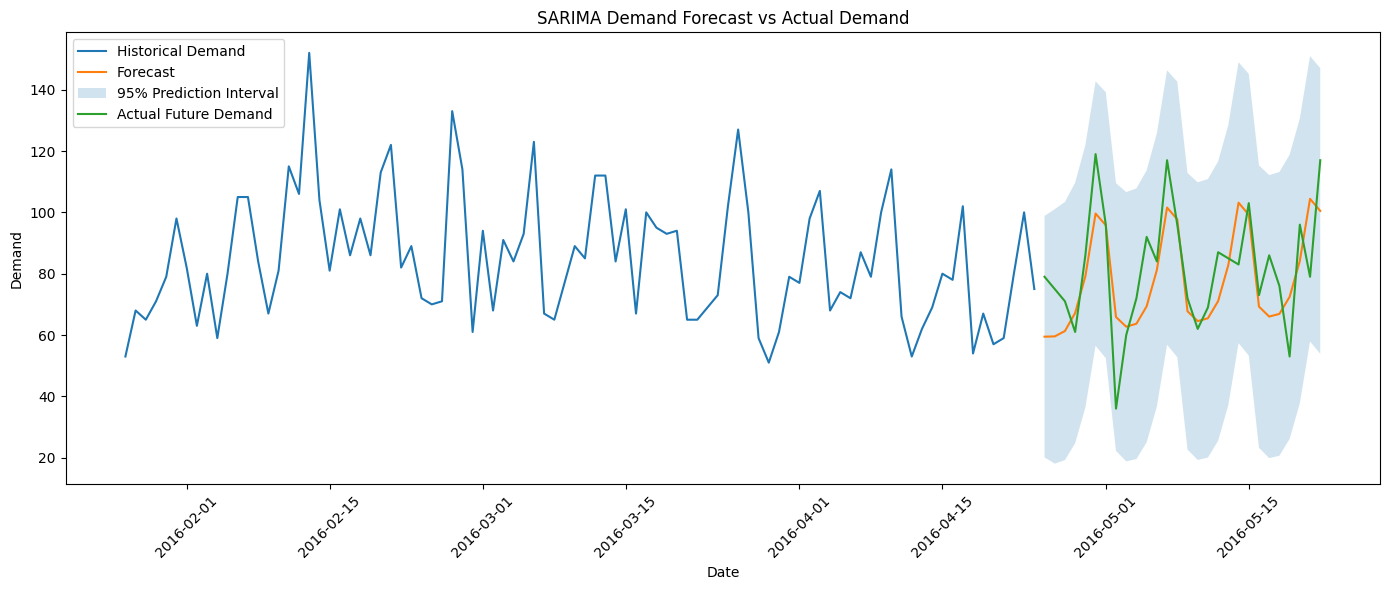

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

historical_plot = ts.iloc[-90:]

plt.plot(
    historical_plot.index,
    historical_plot["Demand"],
    label="Historical Demand"
)

plt.plot(
    forecast_mean.index,
    forecast_mean.values,
    label="Forecast"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.plot(
    future_demand["date"],
    future_demand["actual_demand"],
    label="Actual Future Demand"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("SARIMA Demand Forecast vs Actual Demand")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

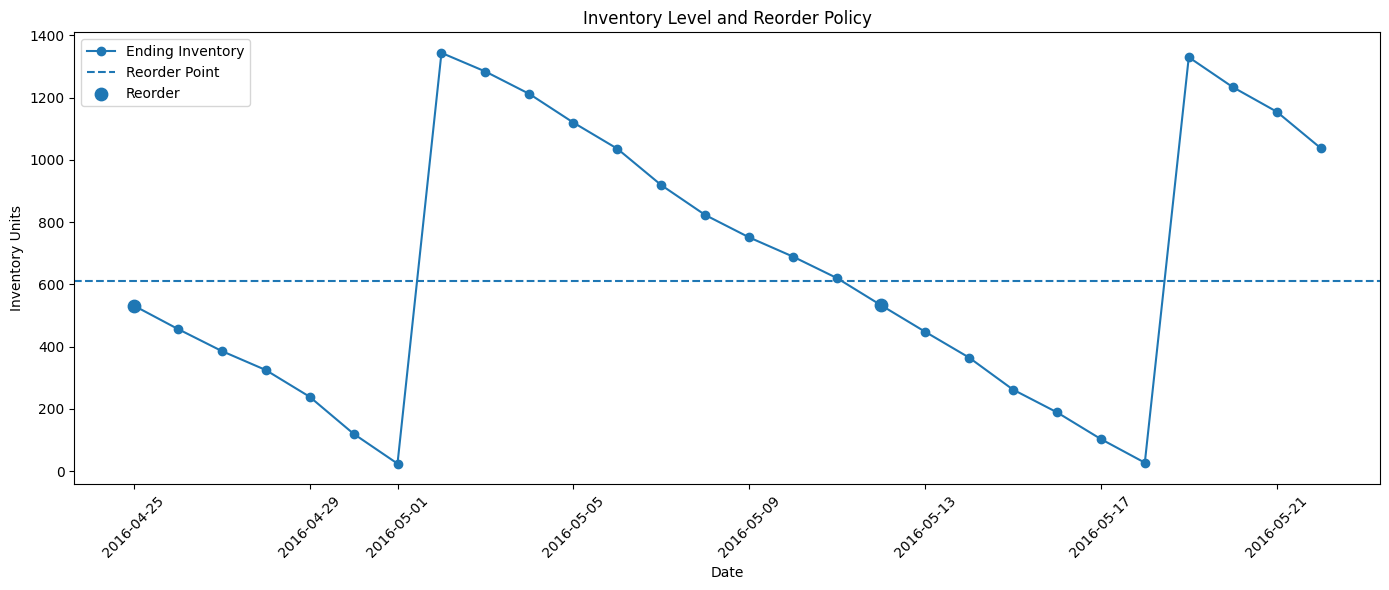

In [119]:
plt.figure(figsize=(14, 6))

plt.plot(
    inventory_simulation["date"],
    inventory_simulation["ending_inventory"],
    marker="o",
    label="Ending Inventory"
)

plt.axhline(
    611,
    linestyle="--",
    label="Reorder Point"
)

reorder_days = inventory_simulation[
    inventory_simulation["order_placed"] > 0
]

plt.scatter(
    reorder_days["date"],
    reorder_days["ending_inventory"],
    s=80,
    label="Reorder"
)

plt.xlabel("Date")
plt.ylabel("Inventory Units")
plt.title("Inventory Level and Reorder Policy")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final project summary table

In [120]:
project_summary = {
    "Selected Item": selected_item,
    "Selected Store": selected_store,
    "Historical Observations": len(ts),
    "Average Daily Demand": average_daily_demand,
    "Annualized Demand": annual_demand,
    "Final Model": "SARIMA(2,0,1)(1,0,1,7)",
    "Test MAE": 16.3432,
    "Test RMSE": 21.3951,
    "28-Day Future MAE": 11.3965,
    "28-Day Future RMSE": 14.0839,
    "28-Day Future MAPE": 15.5379,
    "Lead Time": 7,
    "Safety Stock (95%)": 88.8993,
    "Reorder Point (95%)": 611.0169,
    "EOQ": 1356.3347,
    "28-Day Fill Rate": 1.0,
    "Stockout Units": 0,
    "Number of Orders": 2,
    "Total Inventory Cost": 201.7286
}

project_summary_df = pd.DataFrame(
    project_summary.items(),
    columns=["Metric", "Value"]
)

project_summary_df

,Metric,Value
0,Selected Item,FOODS_3_586
1,Selected Store,TX_2
2,Historical Observations,1913
3,Average Daily Demand,100.802405
4,Annualized Demand,36792.877679
5,Final Model,"SARIMA(2,0,1)(1,0,1,7)"
6,Test MAE,16.3432
7,Test RMSE,21.3951
8,28-Day Future MAE,11.3965
9,28-Day Future RMSE,14.0839


### Saving the model 

In [121]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_sarima_result,
    "../models/final_sarima_model.pkl"
)

print("Final SARIMA model saved successfully.")

Final SARIMA model saved successfully.


In [122]:
joblib.dump(
    ts,
    "../models/historical_demand.pkl"
)

print("Historical demand series saved successfully.")

Historical demand series saved successfully.


In [123]:
inventory_parameters = {
    "selected_item": selected_item,
    "selected_store": selected_store,

    "average_daily_demand": average_daily_demand,
    "annual_demand": annual_demand,

    "lead_time": 7,
    "service_level": 0.95,

    "z_value": 1.6448536269514722,

    "residual_std": residual_std,

    "safety_stock": 88.8993,
    "reorder_point": 611.0169,

    "ordering_cost": 50,
    "holding_cost": 2,

    "eoq": 1356.3347
}

joblib.dump(
    inventory_parameters,
    "../models/inventory_parameters.pkl"
)

print("Inventory parameters saved successfully.")

Inventory parameters saved successfully.


In [124]:
model_comparison = pd.DataFrame({
    "Model": [
        "SARIMA(2,0,1)(1,0,1,7)",
        "SARIMAX(2,0,1)(1,0,1,7) - Price + Event",
        "SARIMAX(2,0,1)(1,0,1,7) - Price",
        "SARIMAX(1,0,1)(1,0,1,7) - Price + Event"
    ],
    "Validation_MAE": [
        16.0253,
        22.3501,
        22.1928,
        21.4192
    ],
    "Validation_RMSE": [
        21.2355,
        27.0085,
        26.8379,
        26.1328
    ],
    "Validation_MAPE": [
        45.9761,
        60.4848,
        60.2893,
        58.4365
    ]
})

joblib.dump(
    model_comparison,
    "../models/model_comparison.pkl"
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [125]:
future_results = future_demand.copy()

future_results["forecast"] = forecast_mean.values
future_results["lower_95"] = forecast_ci.iloc[:, 0].values
future_results["upper_95"] = forecast_ci.iloc[:, 1].values

joblib.dump(
    future_results,
    "../models/future_forecast_results.pkl"
)

print("Future forecast results saved successfully.")

Future forecast results saved successfully.


In [126]:
import os

model_files = [
    "../models/final_sarima_model.pkl",
    "../models/historical_demand.pkl",
    "../models/inventory_parameters.pkl",
    "../models/model_comparison.pkl",
    "../models/future_forecast_results.pkl"
]

for file in model_files:
    print(file, "->", os.path.exists(file))

../models/final_sarima_model.pkl -> True
../models/historical_demand.pkl -> True
../models/inventory_parameters.pkl -> True
../models/model_comparison.pkl -> True
../models/future_forecast_results.pkl -> True
